In [1]:
### read the json file fleet_kincadeFire/Ladris_example/Forecast.geojson
import json
import geopandas as gpd
import matplotlib.pyplot as plt

with open('fleet_kincadeFire/Ladris_example/37hr_2dest/Forecast.geojson') as f:
    data = json.load(f)

### print the keys of data
print(data.keys())

dict_keys(['type', 'features', 'properties'])


In [2]:
### Redwood is 101
### CA 12 is 12
### Gravenstein is 116


### for each feature in data['features']
for feature in data['features']:
    ### check if 'properties' 'Name' has 101 in it
    if 'Gravenstein' in feature['properties']['Name']:
        ### print the feature
        print(feature)
    #else:
    #    print(feature['properties']['Name'])

{'type': 'Feature', 'geometry': {'type': 'LineString', 'coordinates': [[-122.7202669, 38.3322262], [-122.7198903, 38.3321769]]}, 'properties': {'GUID': 28887105, 'Name': 'Gravenstein Highway', 'Lane Count': 1, 'Length (m)': 33, 'congestionLevel': 4, 'congestion_percentage_by_time': [[5355, 0], [10710, 0], [16065, 0], [21421, 0], [26776, 0], [32131, 0], [37487, 0], [42842, 97], [48197, 97], [53553, 97], [58908, 97], [64263, 97], [69618, 97], [74974, 97], [80329, 97], [85684, 97], [91040, 97], [96395, 97], [101750, 97], [107106, 97], [112461, 97], [117816, 0], [123171, 0], [128527, 0], [133882, 0]]}}
{'type': 'Feature', 'geometry': {'type': 'LineString', 'coordinates': [[-122.818132, 38.3929617], [-122.8180944, 38.392903], [-122.8180642, 38.3928461]]}, 'properties': {'GUID': 28750041, 'Name': 'Gravenstein Highway', 'Lane Count': 1, 'Length (m)': 14, 'congestionLevel': 4, 'congestion_percentage_by_time': [[5355, 0], [10710, 0], [16065, 0], [21421, 0], [26776, 97], [32131, 97], [37487, 97]

In [3]:
### create a geopandas dataframe that contains GUID, Name, congestion_percentage_by_time, and geometry LineString
ladris_gdf = gpd.GeoDataFrame.from_features(data['features'])
ladris_gdf = ladris_gdf[['GUID', 'Name', 'congestion_percentage_by_time', 'geometry']]
ladris_gdf = ladris_gdf.set_crs(epsg=4326)
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38...."
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38..."
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38..."
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38..."
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38..."


In [4]:
### read fleet_kincadeFire/Ladris_example/kincade_road_network/guid_speed.csv and store the first column as a key and the second column as a value in a dictionary
guid_speed = {}
with open('fleet_kincadeFire/Ladris_example/kincade_road_network/guid_speed.csv') as f:
    for line in f:
        key, value = line.strip().split(',')
        guid_speed[int(key)] = float(value)  
print(len(guid_speed))

218569


In [5]:
### for each row of ladris_gdf map the GUID to guid_speed and store it in a new column called speed
ladris_gdf['speed'] = ladris_gdf['GUID'].map(guid_speed)
ladris_gdf.head()



,GUID,Name,congestion_percentage_by_time,geometry,speed
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0


# Process Ladris output data and get travel time per segment

In [6]:
import pandas as pd
data = pd.read_csv('PRJ-3226/Highway_Vehicle_Routing_Data_R1.csv')

In [7]:
data.head()

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY
0,User1,38.434102,-122.696106,1571302260000,38.360030,-122.505948,1571303700000,Hwy 12,Hwy 12
1,User1,38.429124,-122.563283,1571618820000,38.535854,-122.799232,1571627580000,Hwy 12,Hwy 101
2,User1,38.462512,-122.644908,1571932920000,38.455989,-122.627828,1571939340000,Hwy 12,Hwy 12
3,User2,38.582761,-122.840816,1571268060000,38.467404,-122.728035,1571269320000,Hwy 101,Hwy 101
4,User2,38.233902,-122.618472,1571665500000,38.193047,-122.600319,1571666640000,Hwy 101,Hwy 101


In [8]:
### convert Entrance_TIMESTAMP and Exit_TIMESTAMP to datetime
### convert Entrance_TIMESTAMP and Exit_TIMESTAMP from milliseconds to datetime
data['Entrance_TIMESTAMP'] = pd.to_datetime(data['Entrance_TIMESTAMP'], unit='ms')
data['Exit_TIMESTAMP'] = pd.to_datetime(data['Exit_TIMESTAMP'], unit='ms')
data['Travel_Time'] = (data['Exit_TIMESTAMP'] - data['Entrance_TIMESTAMP']).dt.total_seconds() / 60  # Convert to minutes 
data.head()

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time
0,User1,38.434102,-122.696106,2019-10-17 08:51:00,38.360030,-122.505948,2019-10-17 09:15:00,Hwy 12,Hwy 12,24.0
1,User1,38.429124,-122.563283,2019-10-21 00:47:00,38.535854,-122.799232,2019-10-21 03:13:00,Hwy 12,Hwy 101,146.0
2,User1,38.462512,-122.644908,2019-10-24 16:02:00,38.455989,-122.627828,2019-10-24 17:49:00,Hwy 12,Hwy 12,107.0
3,User2,38.582761,-122.840816,2019-10-16 23:21:00,38.467404,-122.728035,2019-10-16 23:42:00,Hwy 101,Hwy 101,21.0
4,User2,38.233902,-122.618472,2019-10-21 13:45:00,38.193047,-122.600319,2019-10-21 14:04:00,Hwy 101,Hwy 101,19.0


In [9]:
import numpy as np
### add a column for distance that calculates the distance between to Lat Long points using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000  # radius of Earth in meters
    phi_1 = np.radians(lat1)
    phi_2 = np.radians(lat2)

    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2.0) ** 2 + np.cos(phi_1) * np.cos(phi_2) * np.sin(delta_lambda / 2.0) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    meters = R * c  # output distance in meters
    ### convert meters to miles
    meters = meters * 0.000621371
    return meters

data['Distance'] = data.apply(lambda x: haversine(x['Entrance_LAT'], x['Entrance_LON'], x['Exit_LAT'], x['Exit_LON']), axis=1)
### calculate average speed in mph
data['Avg_Speed'] = data['Distance'] / (data['Travel_Time'] / 60)
data.head()

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed
0,User1,38.434102,-122.696106,2019-10-17 08:51:00,38.360030,-122.505948,2019-10-17 09:15:00,Hwy 12,Hwy 12,24.0,11.498809,28.747023
1,User1,38.429124,-122.563283,2019-10-21 00:47:00,38.535854,-122.799232,2019-10-21 03:13:00,Hwy 12,Hwy 101,146.0,14.738999,6.057123
2,User1,38.462512,-122.644908,2019-10-24 16:02:00,38.455989,-122.627828,2019-10-24 17:49:00,Hwy 12,Hwy 12,107.0,1.028137,0.576526
3,User2,38.582761,-122.840816,2019-10-16 23:21:00,38.467404,-122.728035,2019-10-16 23:42:00,Hwy 101,Hwy 101,21.0,10.034531,28.670089
4,User2,38.233902,-122.618472,2019-10-21 13:45:00,38.193047,-122.600319,2019-10-21 14:04:00,Hwy 101,Hwy 101,19.0,2.989884,9.441740


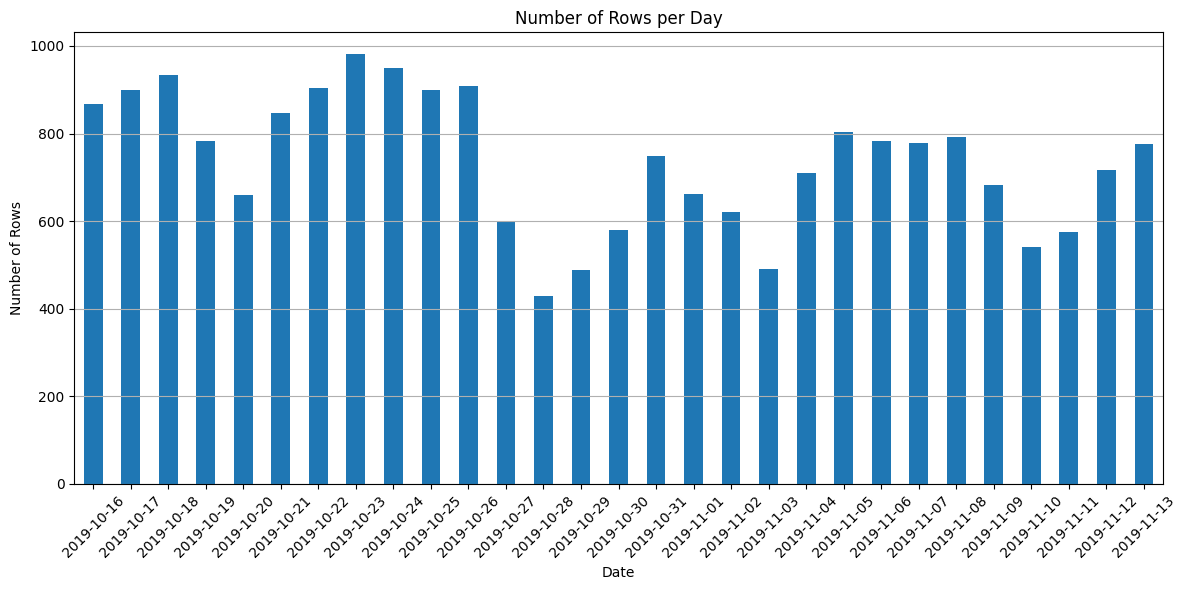

In [10]:
### plot the numer of rows per day
data['Date'] = data['Entrance_TIMESTAMP'].dt.date
daily_counts = data['Date'].value_counts().sort_index()
daily_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Rows per Day')
plt.xlabel('Date')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

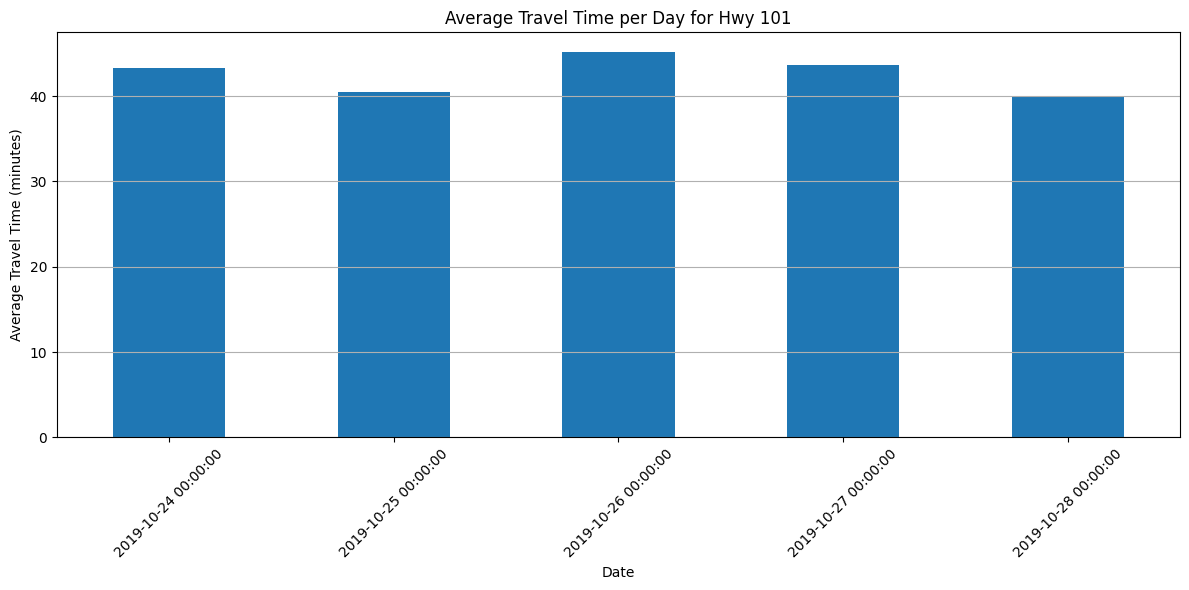

In [11]:
### calculate the average travel time per day for october 24,25,26,27 for rows with Entrance_HWY or Exit_HWY is Hwy 101
avg_travel_time = data[data['Entrance_HWY'] == 'Hwy 101'].groupby('Date')['Travel_Time'].mean()
avg_travel_time = avg_travel_time.reindex(pd.date_range(start='2019-10-24', end='2019-10-28'), fill_value=0)
avg_travel_time.plot(kind='bar', figsize=(12, 6))
plt.title('Average Travel Time per Day for Hwy 101')
plt.xlabel('Date')
plt.ylabel('Average Travel Time (minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


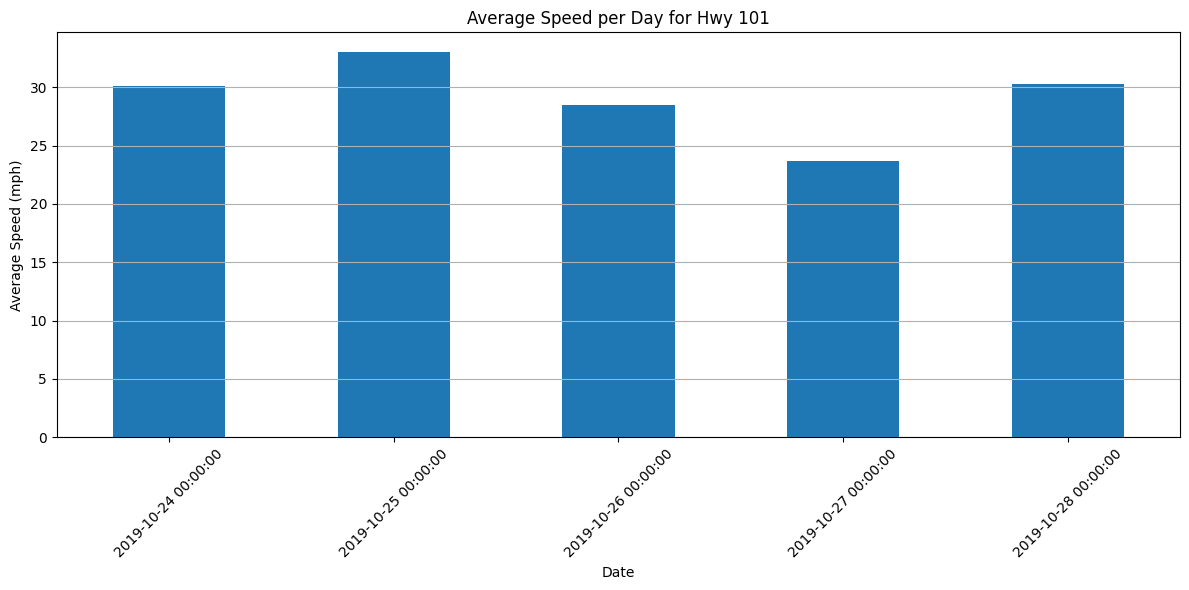

In [12]:
### calculate the average speed per day for october 24,25,26,27, 28 for rows with Entrance_HWY or Exit_HWY is Hwy 101
avg_speed = data[data['Entrance_HWY'] == 'Hwy 101'].groupby('Date')['Avg_Speed'].mean()
avg_speed = avg_speed.reindex(pd.date_range(start='2019-10-24', end='2019-10-28'), fill_value=0)
avg_speed.plot(kind='bar', figsize=(12, 6))
plt.title('Average Speed per Day for Hwy 101')
plt.xlabel('Date')
plt.ylabel('Average Speed (mph)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3027984/294996950.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


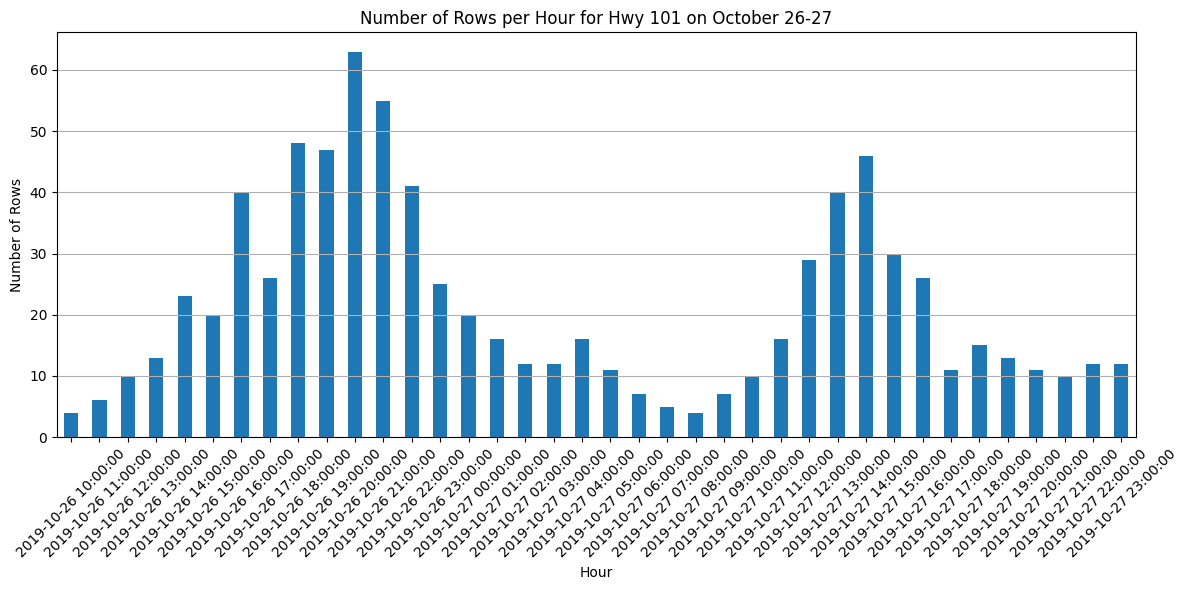

In [13]:
### for October 26 from 10am to October 27 plot the number of rows per hour for Entrance_HWY or Exit_HWY is Hwy 101
import matplotlib.pyplot as plt
# Filter data for October 26 from 10am to October 27
filtered_data = data[(data['Entrance_TIMESTAMP'] >= '2019-10-26 10:00:00') & (data['Entrance_TIMESTAMP'] < '2019-10-28 00:00:00') & (data['Entrance_HWY'] == 'Hwy 101')]
filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')
hourly_counts = filtered_data['Hour'].value_counts().sort_index()
hourly_counts.plot(kind='bar', figsize=(12, 6))
plt.title('Number of Rows per Hour for Hwy 101 on October 26-27')
plt.xlabel('Hour')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [14]:
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry,speed
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0


In [15]:
### print the total number of hourly_counts
print(f"Total number of hourly counts: {len(hourly_counts)}")
print(f"Total number of rows in data: {len(data)}")
print(f"Total number of unique dates: {data['Date'].nunique()}")
print(f"Total number of unique segments: {len(ladris_gdf)}")
print(f"Total number of unique segment IDs in segments_df: {ladris_gdf['GUID'].nunique()}")
print(f"Total number of unique link IDs in segments_df: {ladris_gdf['Name'].nunique()}")
print(f"Total number of unique link names in segments_df: {ladris_gdf['Name'].nunique()}")

### print the sum of the hourly_counts count values
print(f"Sum of hourly counts: {hourly_counts.sum()}")

Total number of hourly counts: 38
Total number of rows in data: 21413
Total number of unique dates: 29
Total number of unique segments: 18280
Total number of unique segment IDs in segments_df: 18280
Total number of unique link IDs in segments_df: 1412
Total number of unique link names in segments_df: 1412
Sum of hourly counts: 812


In [16]:
### print unique names of highways in data
unique_highways = data['Entrance_HWY'].unique()
print(f"Unique highways in data: {unique_highways}")

Unique highways in data: ['Hwy 12' 'Hwy 101' 'Hwy 37' 'Hwy 128' 'Hwy 116' 'Hwy 1']


In [17]:
### Redwood is 101
### CA 12 is 12
### Gravenstein is 116

### Reduce unique_highways to only 'Hwy 12', 'Hwy 101', and 'Hwy 116'
unique_highways = ['Hwy 12', 'Hwy 101', 'Hwy 116']

/tmp/ipykernel_3027984/3144618622.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


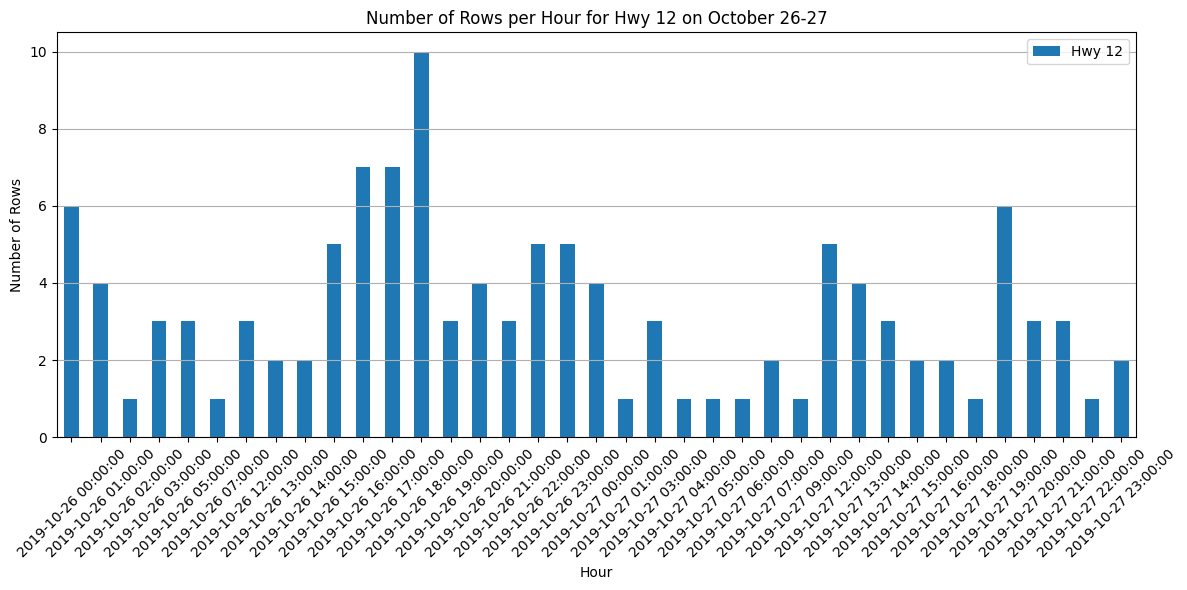

/tmp/ipykernel_3027984/3144618622.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


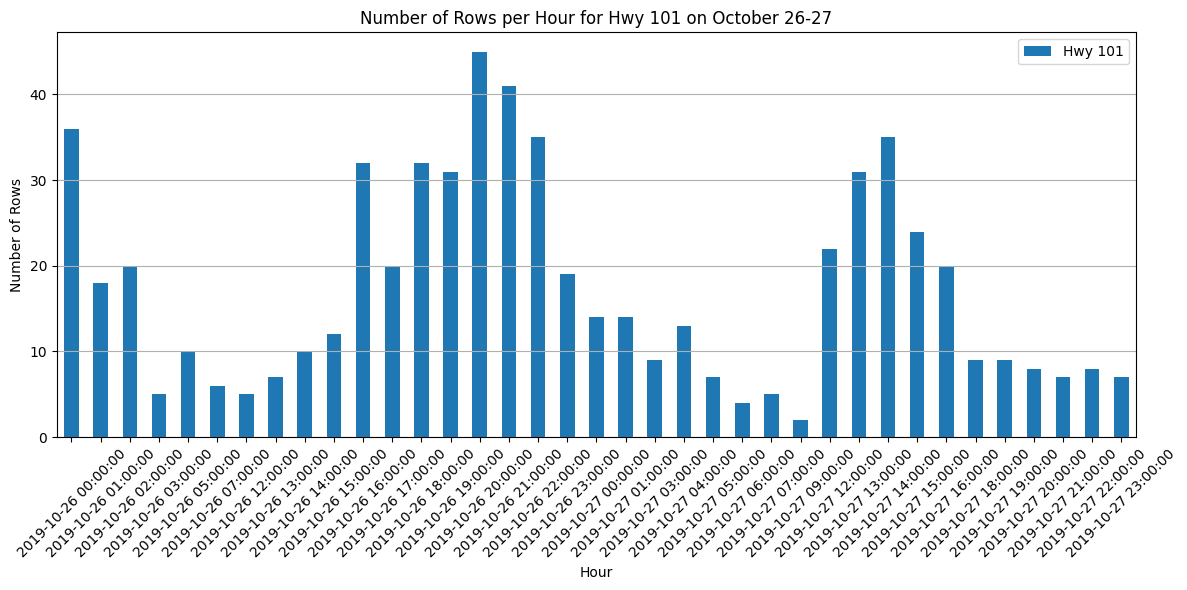

/tmp/ipykernel_3027984/3144618622.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


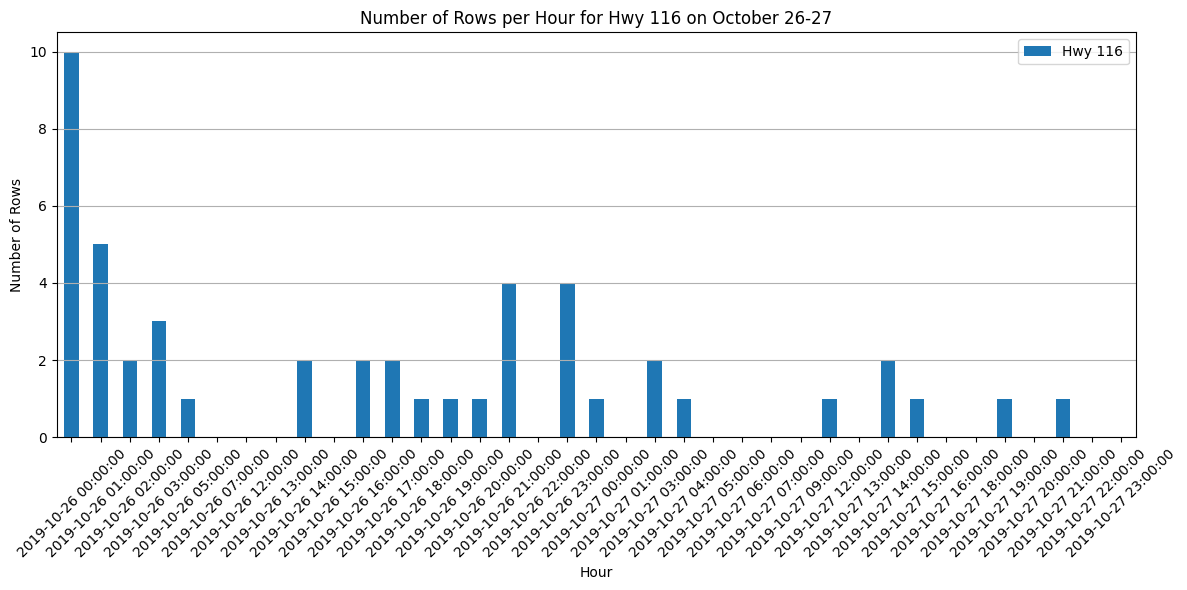

In [18]:
### for October 26 from 10am to October 27 plot the number of rows per hour for Entrance_HWY or Exit_HWY is one of the unique highways
total_hourly_counts = pd.Series(dtype=int)
total_filtered_data = pd.DataFrame()
for highway in unique_highways:
    filtered_data = data[(data['Entrance_TIMESTAMP'] >= '2019-10-26 00:00:00') & (data['Entrance_TIMESTAMP'] < '2019-10-28 00:00:00') & (data['Entrance_HWY'] == highway) & (data['Exit_HWY'] == highway)] 
    filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')
    
    hourly_counts = filtered_data['Hour'].value_counts().sort_index()
    
    total_filtered_data = pd.concat([total_filtered_data, filtered_data], ignore_index=True)

    ### add the hourly_counts to total_hourly_counts
    if total_hourly_counts.empty:
        total_hourly_counts = hourly_counts
    else:
        # Align indices and fill missing values with 0
        hourly_counts = hourly_counts.reindex(total_hourly_counts.index, fill_value=0)
        # Add the counts
        total_hourly_counts += hourly_counts    
    
    if not hourly_counts.empty:
        hourly_counts.plot(kind='bar', figsize=(12, 6), label=highway)
        plt.title(f'Number of Rows per Hour for {highway} on October 26-27')
        plt.xlabel('Hour')
        plt.ylabel('Number of Rows')
        plt.xticks(rotation=45)
        plt.grid(axis='y')
        plt.legend()
        plt.tight_layout()
        plt.show()
        

In [19]:
print(len(total_hourly_counts))
total_hourly_counts

37


Hour
2019-10-26 00:00:00    52
2019-10-26 01:00:00    27
2019-10-26 02:00:00    23
2019-10-26 03:00:00    11
2019-10-26 05:00:00    14
2019-10-26 07:00:00     7
2019-10-26 12:00:00     8
2019-10-26 13:00:00     9
2019-10-26 14:00:00    14
2019-10-26 15:00:00    17
2019-10-26 16:00:00    41
2019-10-26 17:00:00    29
2019-10-26 18:00:00    43
2019-10-26 19:00:00    35
2019-10-26 20:00:00    50
2019-10-26 21:00:00    48
2019-10-26 22:00:00    40
2019-10-26 23:00:00    28
2019-10-27 00:00:00    19
2019-10-27 01:00:00    15
2019-10-27 03:00:00    14
2019-10-27 04:00:00    15
2019-10-27 05:00:00     8
2019-10-27 06:00:00     5
2019-10-27 07:00:00     7
2019-10-27 09:00:00     3
2019-10-27 12:00:00    28
2019-10-27 13:00:00    35
2019-10-27 14:00:00    40
2019-10-27 15:00:00    27
2019-10-27 16:00:00    22
2019-10-27 18:00:00    10
2019-10-27 19:00:00    16
2019-10-27 20:00:00    11
2019-10-27 21:00:00    11
2019-10-27 22:00:00     9
2019-10-27 23:00:00     9
Name: count, dtype: int64

In [20]:
### sum the values of total_hourly_counts
print(f"Sum of total hourly counts: {total_hourly_counts.sum()}")
print(f"Total number of unique hours: {total_hourly_counts.index.nunique()}")

Sum of total hourly counts: 800
Total number of unique hours: 37


In [21]:
filtered_hw101 = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]
filtered_hw12 = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12')]
filtered_hw116 = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116')]
print(len(filtered_hw101), len(filtered_hw12), len(filtered_hw116))

699 120 57


In [22]:
filtered_data.head()

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
862,User93,38.356640,-122.768290,2019-10-26 14:38:00,38.334538,-122.739408,2019-10-26 15:04:00,Hwy 116,Hwy 116,26.0,2.186665,5.046150,2019-10-26,2019-10-26 14:00:00
1133,User111,38.490364,-122.961022,2019-10-26 16:20:00,38.468949,-123.012478,2019-10-26 17:03:00,Hwy 116,Hwy 116,43.0,3.152034,4.398188,2019-10-26,2019-10-26 16:00:00
1702,User182,38.466374,-122.882316,2019-10-26 17:45:00,38.450710,-122.867553,2019-10-26 17:58:00,Hwy 116,Hwy 116,13.0,1.345105,6.208178,2019-10-26,2019-10-26 17:00:00
1750,User184,38.424060,-122.847254,2019-10-26 23:37:00,38.345954,-122.759706,2019-10-26 23:52:00,Hwy 116,Hwy 116,15.0,7.183690,28.734759,2019-10-26,2019-10-26 23:00:00
2746,User308,38.405692,-122.837126,2019-10-26 00:48:00,38.352220,-122.765200,2019-10-26 01:00:00,Hwy 116,Hwy 116,12.0,5.369064,26.845322,2019-10-26,2019-10-26 00:00:00


In [23]:
### Summarize filtered_data
filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')
summary = filtered_data.groupby('Hour').agg({
    'Entrance_HWY': 'count',
    'Exit_HWY': 'count',
    'Travel_Time': 'mean',
    'Avg_Speed': 'mean'
}).rename(columns={
    'Entrance_HWY': 'Entrance_Count',
    'Exit_HWY': 'Exit_Count',
    'Travel_Time': 'Average_Travel_Time',
    'Avg_Speed': 'Average_Speed'
})
print(summary.head())

                     Entrance_Count  Exit_Count  Average_Travel_Time  \
Hour                                                                   
2019-10-26 00:00:00              10          10            18.100000   
2019-10-26 01:00:00               5           5            18.200000   
2019-10-26 02:00:00               2           2            45.000000   
2019-10-26 03:00:00               3           3            88.000000   
2019-10-26 04:00:00               3           3            18.666667   

                     Average_Speed  
Hour                                
2019-10-26 00:00:00      21.879771  
2019-10-26 01:00:00      16.337447  
2019-10-26 02:00:00      12.152470  
2019-10-26 03:00:00      18.918759  
2019-10-26 04:00:00      23.086174  


/tmp/ipykernel_3027984/1986848991.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Hour'] = filtered_data['Entrance_TIMESTAMP'].dt.floor('H')


In [24]:
summary

,Entrance_Count,Exit_Count,Average_Travel_Time,Average_Speed
Hour,,,,
2019-10-26 00:00:00,10,10,18.100000,21.879771
2019-10-26 01:00:00,5,5,18.200000,16.337447
2019-10-26 02:00:00,2,2,45.000000,12.152470
2019-10-26 03:00:00,3,3,88.000000,18.918759
2019-10-26 04:00:00,3,3,18.666667,23.086174
2019-10-26 05:00:00,1,1,10.000000,31.533977
2019-10-26 09:00:00,1,1,70.000000,11.952056
2019-10-26 14:00:00,2,2,26.000000,11.004054
2019-10-26 16:00:00,2,2,26.500000,13.460703


In [25]:
total_filtered_data

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
0,User37,38.307287,-122.478139,2019-10-26 17:37:00,38.294198,-122.475950,2019-10-26 17:58:00,Hwy 12,Hwy 12,21.0,0.912118,2.606051,2019-10-26,2019-10-26 17:00:00
1,User98,38.319046,-122.485520,2019-10-26 20:25:00,38.302395,-122.475478,2019-10-26 20:35:00,Hwy 12,Hwy 12,10.0,1.272787,7.636719,2019-10-26,2019-10-26 20:00:00
2,User108,38.343465,-122.497494,2019-10-26 01:36:00,38.458950,-122.673962,2019-10-26 01:55:00,Hwy 12,Hwy 12,19.0,12.448713,39.311727,2019-10-26,2019-10-26 01:00:00
3,User108,38.449852,-122.683446,2019-10-26 05:12:00,38.392817,-122.530753,2019-10-26 05:26:00,Hwy 12,Hwy 12,14.0,9.156916,39.243925,2019-10-26,2019-10-26 05:00:00
4,User108,38.305785,-122.477710,2019-10-26 23:14:00,38.355610,-122.502558,2019-10-26 23:32:00,Hwy 12,Hwy 12,18.0,3.696630,12.322099,2019-10-26,2019-10-26 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,User2028,38.392002,-122.817728,2019-10-26 03:15:00,38.468563,-122.884547,2019-10-26 03:26:00,Hwy 116,Hwy 116,11.0,6.407988,34.952660,2019-10-26,2019-10-26 03:00:00
872,User2156,38.389170,-122.815711,2019-10-26 00:32:00,38.412086,-122.842662,2019-10-26 00:43:00,Hwy 116,Hwy 116,11.0,2.153280,11.745163,2019-10-26,2019-10-26 00:00:00
873,User2170,38.345782,-122.759535,2019-10-26 21:35:00,38.334367,-122.736961,2019-10-26 23:13:00,Hwy 116,Hwy 116,98.0,1.455552,0.891154,2019-10-26,2019-10-26 21:00:00
874,User2321,38.415091,-122.845280,2019-10-26 23:33:00,38.340804,-122.753055,2019-10-26 23:48:00,Hwy 116,Hwy 116,15.0,7.162274,28.649095,2019-10-26,2019-10-26 23:00:00


In [26]:
### Can I randomly split the total_filtered_data into two parts, one for training and one for testing?
from sklearn.model_selection import train_test_split
train_data, test_data = train_test_split(total_filtered_data, test_size=0.2, random_state=42)
print(f"Training data size: {len(train_data)}")
print(f"Testing data size: {len(test_data)}")
print(f"Total data size: {len(total_filtered_data)}")
print(f"Total number of unique highways in training data: {train_data['Entrance_HWY'].nunique()}")
print(f"Total number of unique highways in testing data: {test_data['Entrance_HWY'].nunique()}")
print(f"Total number of unique highways in total data: {total_filtered_data['Entrance_HWY'].nunique()}")
print(f"Total number of unique segment IDs in total data: {total_filtered_data['Entrance_HWY'].nunique()}")
print(f"Total number of unique segment IDs in segments_df: {ladris_gdf['GUID'].nunique()}")
print(f"Total number of unique link IDs in segments_df: {ladris_gdf['Name'].nunique()}")
print(f"Total number of unique link names in segments_df: {ladris_gdf['Name'].nunique()}") 

Training data size: 700
Testing data size: 176
Total data size: 876
Total number of unique highways in training data: 3
Total number of unique highways in testing data: 3
Total number of unique highways in total data: 3
Total number of unique segment IDs in total data: 3
Total number of unique segment IDs in segments_df: 18280
Total number of unique link IDs in segments_df: 1412
Total number of unique link names in segments_df: 1412


In [27]:
### How much of training data and testing data have Entrance_HWY == Exit_HWY?
train_entrance_exit_match = train_data[train_data['Entrance_HWY'] == train_data['Exit_HWY']]
test_entrance_exit_match = test_data[test_data['Entrance_HWY'] == test_data['Exit_HWY']]
print(f"Training data with Entrance_HWY == Exit_HWY: {len(train_entrance_exit_match)}")
print(f"Testing data with Entrance_HWY == Exit_HWY: {len(test_entrance_exit_match)}")
print(f"Total training data size: {len(train_data)}")
print(f"Total testing data size: {len(test_data)}")
print(f"Total data size: {len(total_filtered_data)}")   

Training data with Entrance_HWY == Exit_HWY: 700
Testing data with Entrance_HWY == Exit_HWY: 176
Total training data size: 700
Total testing data size: 176
Total data size: 876


In [28]:
### print unique names of highways in data
unique_highways = data['Entrance_HWY'].unique()
print(f"Unique highways in data: {unique_highways}")
### Reduce unique_highways to only 'Hwy 12', 'Hwy 101', and 'Hwy 116'
unique_highways = ['Hwy 12', 'Hwy 101', 'Hwy 116']

Unique highways in data: ['Hwy 12' 'Hwy 101' 'Hwy 37' 'Hwy 128' 'Hwy 116' 'Hwy 1']


In [29]:
### convert segments_df[segments_df['linkName']=='US-101']['freeflowSpeed'] to integers
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry,speed
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0


In [30]:
### pring ladris_gdf where Redwood is in Name
ladris_gdf[ladris_gdf['Name'].str.contains('Gravenstein Highway', na=False)]

,GUID,Name,congestion_percentage_by_time,geometry,speed
98,28887105,Gravenstein Highway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72027 38.33223, -122.71989 38...",49.0
379,28750041,Gravenstein Highway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.81813 38.39296, -122.81809 38...",49.0
462,28726286,Gravenstein Highway South,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.78951 38.37304, -122.78806 38...",49.0
500,28740326,Gravenstein Highway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.75237 38.34049, -122.75118 38...",49.0
580,28852781,Gravenstein Highway North,"[[5355, 0], [10710, 0], [16065, 0], [21421, 90...","LINESTRING (-122.87608 38.4603, -122.8745 38.4...",49.0
...,...,...,...,...,...
18140,28749032,Gravenstein Highway North,"[[5355, 0], [10710, 0], [16065, 97], [21421, 9...","LINESTRING (-122.85722 38.43559, -122.85721 38...",49.0
18210,28726293,Gravenstein Highway South,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.78397 38.36898, -122.78386 38...",49.0
18217,28726258,Gravenstein Highway South,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.79403 38.37627, -122.7931 38....",49.0
18241,28748866,Gravenstein Highway North,"[[5355, 0], [10710, 0], [16065, 0], [21421, 97...","LINESTRING (-122.84614 38.42209, -122.84613 38...",49.0


In [31]:
### Redwood is 101
### CA 12 is 12
### Gravenstein is 116

### get rows of ladris_gdf where column Name contains '101'
### get segment ID for ladris_gdf[ladris_gdf['Name']=='US-101']['GUID']
ladris_hw101_segments = ladris_gdf[ladris_gdf['Name'] == 'Redwood Highway']
ladris_hw116_segments = ladris_gdf[ladris_gdf['Name'] == 'Gravenstein Highway']
ladris_hw12_segments = ladris_gdf[ladris_gdf['Name'] == 'CA 12']
print(len(ladris_hw101_segments), len(ladris_hw116_segments), len(ladris_hw12_segments))


50 79 13


In [32]:
### get total_data['speed'] for each segment in fleet_hw101_segments
ladris_speed_hw101 = {}
ladris_speed_hw116 = {}
ladris_speed_hw12 = {}
for seg_id in ladris_hw101_segments['GUID']:
    if seg_id in ladris_gdf['GUID'].values:
        seg_data = ladris_gdf[ladris_gdf['GUID'] == seg_id]
        ladris_speed_hw101[seg_id] = seg_data['speed'].values[0]
for seg_id in ladris_hw116_segments['GUID']:
    if seg_id in ladris_gdf['GUID'].values:
        seg_data = ladris_gdf[ladris_gdf['GUID'] == seg_id]
        ladris_speed_hw116[seg_id] = seg_data['speed'].values[0]
for seg_id in ladris_hw12_segments['GUID']:
    if seg_id in ladris_gdf['GUID'].values:
        seg_data = ladris_gdf[ladris_gdf['GUID'] == seg_id]
        ladris_speed_hw12[seg_id] = seg_data['speed'].values[0]




In [33]:
print(len(ladris_speed_hw101), len(ladris_speed_hw116), len(ladris_speed_hw12))

50 79 13


In [365]:
ladris_speed_hw12

{28770803: 59.0,
 28770380: 59.0,
 28733813: 59.0,
 28910200: 59.0,
 28770392: 59.0,
 28770788: 59.0,
 28733809: 59.0,
 28770888: 59.0,
 28906653: 59.0,
 28906657: 59.0,
 28910228: 59.0,
 28842907: 59.0,
 28733867: 59.0}

In [34]:
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry,speed
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0


In [35]:
### create a dictionary that maps GUID as the key and congestion_percentage_by_time as the value for ladris_gdf
ladris_congestion = {}
for index, row in ladris_gdf.iterrows():
    ladris_congestion[row['GUID']] = row['congestion_percentage_by_time']

print(len(ladris_congestion))

18280


# Current Variables
 - ladris lat/lon by guid -> ladris_gdf (dataview with GUID and geometry) 
 - ladris_speed_hw101 is the speed limits for the ladris models 101
 - ladris_congestion is a dictionary with key being GUID and value bein a list of tuples with time and congestion percentage
 - ladris_congestion_speed -> converted ladris_congestion to be speed values per time

In [36]:
### Print ladris_gdf where GUID is 28857930 
ladris_gdf[ladris_gdf['GUID'] == 28857930]

,GUID,Name,congestion_percentage_by_time,geometry,speed
645,28857930,Redwood Highway,"[[5355, 98], [10710, 98], [16065, 98], [21421,...","LINESTRING (-122.75673 38.4964, -122.7561 38.4...",59.0


In [37]:
ladris_congestion[28857930]

[[5355, 98],
 [10710, 98],
 [16065, 98],
 [21421, 98],
 [26776, 98],
 [32131, 98],
 [37487, 98],
 [42842, 98],
 [48197, 98],
 [53553, 98],
 [58908, 98],
 [64263, 98],
 [69618, 98],
 [74974, 98],
 [80329, 0],
 [85684, 0],
 [91040, 0],
 [96395, 0],
 [101750, 0],
 [107106, 0],
 [112461, 0],
 [117816, 0],
 [123171, 0],
 [128527, 0],
 [133882, 0]]

In [38]:
filtered_hw101

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
120,User4,38.439896,-122.719838,2019-10-26 06:36:00,38.519546,-122.784254,2019-10-26 06:49:00,Hwy 101,Hwy 101,13.0,6.513476,30.062198,2019-10-26,2019-10-26 06:00:00
121,User4,38.482038,-122.736489,2019-10-26 17:22:00,38.430883,-122.714817,2019-10-26 17:44:00,Hwy 101,Hwy 101,22.0,3.723896,10.156080,2019-10-26,2019-10-26 17:00:00
122,User4,38.558857,-122.820303,2019-10-27 12:23:00,38.459379,-122.726361,2019-10-27 12:33:00,Hwy 101,Hwy 101,10.0,8.546274,51.277643,2019-10-27,2019-10-27 12:00:00
123,User4,38.460023,-122.726705,2019-10-27 14:23:00,38.477919,-122.731983,2019-10-27 16:12:00,Hwy 101,Hwy 101,109.0,1.269031,0.698549,2019-10-27,2019-10-27 14:00:00
124,User9,38.374793,-122.716104,2019-10-27 02:55:00,38.200342,-122.598903,2019-10-27 03:23:00,Hwy 101,Hwy 101,28.0,13.626580,29.199814,2019-10-27,2019-10-27 02:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
814,User2493,38.196351,-122.599546,2019-10-26 02:05:00,38.488862,-122.745673,2019-10-26 02:45:00,Hwy 101,Hwy 101,40.0,21.706513,32.559769,2019-10-26,2019-10-26 02:00:00
815,User2503,38.426506,-122.715160,2019-10-26 06:17:00,38.392560,-122.716190,2019-10-26 06:29:00,Hwy 101,Hwy 101,12.0,2.346104,11.730520,2019-10-26,2019-10-26 06:00:00
816,User2505,38.376080,-122.716748,2019-10-27 11:18:00,38.241927,-122.621948,2019-10-27 11:31:00,Hwy 101,Hwy 101,13.0,10.598681,48.916987,2019-10-27,2019-10-27 11:00:00
817,User2508,38.446547,-122.724602,2019-10-27 21:49:00,38.348400,-122.713401,2019-10-27 22:06:00,Hwy 101,Hwy 101,17.0,6.808371,24.029545,2019-10-27,2019-10-27 21:00:00


In [88]:
uniqueRedwoods = []
for i in ladris_gdf['Name']:
    if 'Redwood' in i:
        uniqueRedwoods.append(i)
print(set(uniqueRedwoods))

{'Redwood Drive', 'Redwood Highway', 'Old Redwood Highway'}


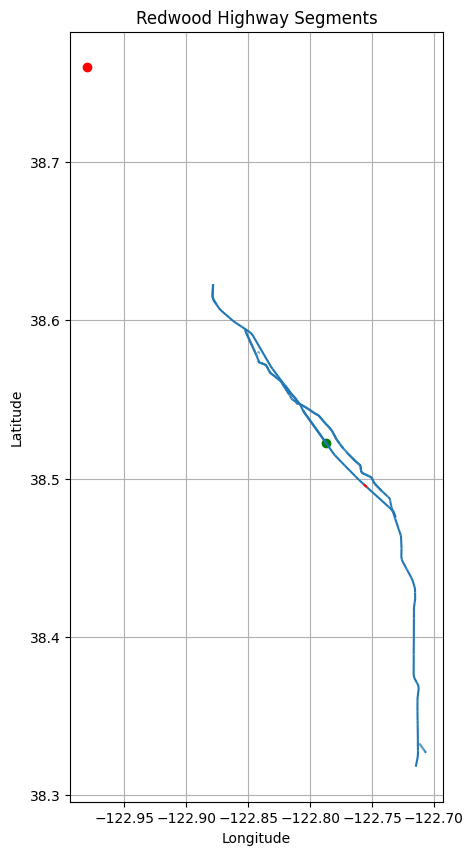

In [90]:
### plot ladris_gdf[ladris_gdf['Name'] == 'Redwood Highway']['geometry'] or ladris_gdf[ladris_gdf['Name'] == 'Old Redwood Highway']['geometry'] or ladris_gdf[ladris_gdf['Name'] == 'Redwood Dr']['geometry']
ladris_gdf[ladris_gdf['Name'] == 'Redwood Highway'].plot(figsize=(10, 10))
ladris_gdf[ladris_gdf['Name'] == 'Old Redwood Highway'].plot(ax=plt.gca())
#ladris_gdf[ladris_gdf['Name'] == 'Redwood Dr'].plot(ax=plt.gca())
### Highlight ladris_gdf[guid] == 28857930
### plot filtered_hw101.iloc[121] with start point red and end point green
ladris_gdf[ladris_gdf['GUID'] == 28857930].plot(ax=plt.gca(), color='red')
plt.scatter(filtered_hw101.iloc[121].Entrance_LON, filtered_hw101.iloc[121].Entrance_LAT, color='red', label='Start Point')
plt.scatter(filtered_hw101.iloc[121].Exit_LON, filtered_hw101.iloc[121].Exit_LAT, color='green', label='End Point')
plt.title('Redwood Highway Segments')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid()
plt.show()


In [40]:
### Create ladris_congestion_speed dictionary that maps GUID to a list of tuples with time and speed
ladris_congestion_speed = {}
for guid, group in ladris_gdf.groupby('GUID'):
    ### create ladris_congestion_speed where key is guid and value is a list of tuples with time and speed where speed is the second tuple for each element in ladris_congestion[guid] divided by 100 and subtracted from 1 multiplied by group['speed'].values[0]
    ladris_congestion_speed[guid] = [(time, (1-(speed / 100)) * group['speed'].values[0]) for time, speed in ladris_congestion[guid]]    

In [41]:
ladris_congestion_speed[28857930]

[(5355, 1.180000000000001),
 (10710, 1.180000000000001),
 (16065, 1.180000000000001),
 (21421, 1.180000000000001),
 (26776, 1.180000000000001),
 (32131, 1.180000000000001),
 (37487, 1.180000000000001),
 (42842, 1.180000000000001),
 (48197, 1.180000000000001),
 (53553, 1.180000000000001),
 (58908, 1.180000000000001),
 (64263, 1.180000000000001),
 (69618, 1.180000000000001),
 (74974, 1.180000000000001),
 (80329, 59.0),
 (85684, 59.0),
 (91040, 59.0),
 (96395, 59.0),
 (101750, 59.0),
 (107106, 59.0),
 (112461, 59.0),
 (117816, 59.0),
 (123171, 59.0),
 (128527, 59.0),
 (133882, 59.0)]

In [42]:
### get a lat/lon for the start of each linestring in ladris_gdf and store it in a new column called start_point
ladris_gdf['start_point'] = ladris_gdf['geometry'].apply(lambda x: (x.coords[0][1], x.coords[0][0]))
ladris_gdf.head()

,GUID,Name,congestion_percentage_by_time,geometry,speed,start_point
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0,"(38.5230097, -122.8074871)"
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0,"(38.4644662, -122.7243532)"
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0,"(38.4157817, -122.7423096)"
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0,"(38.6229129, -122.8757745)"
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0,"(38.5157537, -122.7694732)"


In [43]:
### get a lat/lon for the end of each linestring in ladris_gdf and store it in a new column called end_point
ladris_gdf['end_point'] = ladris_gdf['geometry'].apply(lambda x: (x.coords[-1][1], x.coords[-1][0]))
ladris_gdf.head()   

,GUID,Name,congestion_percentage_by_time,geometry,speed,start_point,end_point
0,28793424,Day Road,"[[5355, 0], [10710, 96], [16065, 96], [21421, ...","LINESTRING (-122.80749 38.52301, -122.8075 38....",27.0,"(38.5230097, -122.8074871)","(38.5224304, -122.8075021)"
1,28795004,Ventura Avenue,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.72435 38.46447, -122.72435 38...",40.0,"(38.4644662, -122.7243532)","(38.4641175, -122.724355)"
2,28894311,Northpoint Parkway,"[[5355, 0], [10710, 0], [16065, 0], [21421, 0]...","LINESTRING (-122.74231 38.41578, -122.74225 38...",40.0,"(38.4157817, -122.7423096)","(38.4159528, -122.7400192)"
3,28918323,Grove Street,"[[5355, 0], [10710, 97], [16065, 97], [21421, ...","LINESTRING (-122.87577 38.62291, -122.87577 38...",40.0,"(38.6229129, -122.8757745)","(38.6237401, -122.8757817)"
4,28796826,Fulton Road,"[[5355, 97], [10710, 97], [16065, 97], [21421,...","LINESTRING (-122.76947 38.51575, -122.76958 38...",40.0,"(38.5157537, -122.7694732)","(38.5155321, -122.7696255)"


In [370]:
### create ladris_lat_lon_dict dictionary that maps a GUID to a list of two arrays, the first array is the start_point and the second array is the end_point
ladris_lat_long_dict = {}
for index, row in ladris_gdf.iterrows():
    ladris_lat_long_dict[row['GUID']] = [row['start_point'], row['end_point']]

### Create ladris_segment_roadNames dictionary that maps GUID to Name
ladris_segment_roadNames = ladris_gdf.set_index('GUID')['Name'].to_dict()

translate_dict = {}
translate_dict['Redwood Highway'] = 'Hwy 101'
translate_dict['Gravenstein Highway'] = 'Hwy 116'
translate_dict['CA 12'] = 'Hwy 12'


In [371]:
ladris_lat_long_dict

{28793424: [(38.5230097, -122.8074871), (38.5224304, -122.8075021)],
 28795004: [(38.4644662, -122.7243532), (38.4641175, -122.724355)],
 28894311: [(38.4157817, -122.7423096), (38.4159528, -122.7400192)],
 28918323: [(38.6229129, -122.8757745), (38.6237401, -122.8757817)],
 28796826: [(38.5157537, -122.7694732), (38.5155321, -122.7696255)],
 28864535: [(38.4509367, -122.8615641), (38.4506994, -122.8614671)],
 28797125: [(38.5132686, -122.7619619), (38.5132651, -122.7610383)],
 28855415: [(38.4993942, -122.7407099), (38.4993229, -122.740709)],
 28767171: [(38.448869, -122.6987822), (38.4489816, -122.6986581)],
 28906842: [(38.4282044, -122.7249972), (38.4280217, -122.7249784)],
 28860406: [(38.5083544, -122.9288002), (38.5089122, -122.925251)],
 28840069: [(38.4460287, -122.6954276), (38.4452387, -122.695162)],
 28793401: [(38.525571, -122.8101026), (38.5250185, -122.8134613)],
 28801139: [(38.5120034, -122.7797348), (38.5120036, -122.7795685)],
 28801918: [(38.4695869, -122.667137), (

In [372]:
# First, filter to keep only southbound trips
filtered_hw101_southbound = filtered_hw101[filtered_hw101['Exit_LAT'] < filtered_hw101['Entrance_LAT']].copy()

print(f"Original trips: {len(filtered_hw101)}")
print(f"Southbound trips only: {len(filtered_hw101_southbound)}")
print(f"Filtered out {len(filtered_hw101) - len(filtered_hw101_southbound)} northbound trips")

### do the same for hw116 and hw12
filtered_hw116_southbound = filtered_hw116[filtered_hw116['Exit_LAT'] < filtered_hw116['Entrance_LAT']].copy()
filtered_hw12_southbound = filtered_hw12.copy()

print(f"Original trips HW116: {len(filtered_hw116)}")
print(f"Southbound trips only HW116: {len(filtered_hw116_southbound)}")
print(f"Filtered out {len(filtered_hw116) - len(filtered_hw116_southbound)} northbound trips HW116")
print(f"Original trips HW12: {len(filtered_hw12)}")
print(f"Southbound trips only HW12: {len(filtered_hw12_southbound)}")
print(f"Filtered out {len(filtered_hw12) - len(filtered_hw12_southbound)} northbound trips HW12")


Original trips: 699
Southbound trips only: 473
Filtered out 226 northbound trips
Original trips HW116: 57
Southbound trips only HW116: 37
Filtered out 20 northbound trips HW116
Original trips HW12: 120
Southbound trips only HW12: 120
Filtered out 0 northbound trips HW12


In [373]:
# User37	38.439896	-122.719838	
### identify the long lat pair in ladris_lat_long_dict that is closest to (38.439896, -122.719838)
import math    

### determine the direction of the segment based on the angle start and end points
def determine_direction(angle):
    if -22.5 <= angle < 22.5:
        return 'East'
    elif 22.5 <= angle < 67.5:
        return 'Northeast'
    elif 67.5 <= angle < 112.5:
        return 'North'
    elif 112.5 <= angle < 157.5:
        return 'Northwest'
    elif (157.5 <= angle <= 180) or (-180 <= angle < -157.5):
        return 'West'
    elif -157.5 <= angle < -112.5:
        return 'Southwest'
    elif -112.5 <= angle < -67.5:
        return 'South'
    elif -67.5 <= angle < -22.5:
        return 'Southeast'
    else:
        return 'Unknown'
    
def calculate_angle(entrance, exit):
    delta_x = exit[1] - entrance[1]
    delta_y = exit[0] - entrance[0]
    angle = math.atan2(delta_y, delta_x) * (180 / math.pi)
    return angle

def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius of the Earth in kilometers
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2    
    c = 2 * math.asin(math.sqrt(a))
    return R * c
min_distance = float('inf')
closest_segment = None

### total_filtered_data has multiple non-unique ID values with Entrance_LAT and ENTRANCE_LON and Exit_LAT and Exit_LON and Entrance_HWY
### fleet_lat_long_dict has unique id values that are segment IDs with value that is Entrance Lat lon and exist lat lon
### For each total_filtered_data, map entrance lat lon to a segment where fleet_lat_long_dict[segment] that has Entrance_HWY equal to fleet_segment_roadNames[segment]
### save in Entrance_filtered_dict where key is indexID from total_filtered_data and value is segment ID from fleet_lat_long_dict
Entrance_filtered_dict = {}
for filtered in filtered_hw101_southbound.itertuples():
    min_distance = float('inf')
    closest_segment = None
    entrance_lat = filtered.Entrance_LAT
    entrance_lon = filtered.Entrance_LON
    
    for segment in ladris_lat_long_dict:
        segment_road = ladris_segment_roadNames[segment]
        matches_road = (segment_road == filtered.Entrance_HWY or 
                       (segment_road in translate_dict and 
                        translate_dict[segment_road] == filtered.Entrance_HWY))
        
        if matches_road:
            ladris_entrance_lat = ladris_lat_long_dict[segment][0][0]
            ladris_entrance_lon = ladris_lat_long_dict[segment][0][1]
            ladris_exit_lat = ladris_lat_long_dict[segment][1][0]
            ladris_exit_lon = ladris_lat_long_dict[segment][1][1]
            
            distance = haversine_distance(entrance_lat, entrance_lon, ladris_entrance_lat, ladris_entrance_lon)
            
            ### Calculate direction based on segment's own entrance to exit
            angle = calculate_angle((ladris_entrance_lat, ladris_entrance_lon), 
                                   (ladris_exit_lat, ladris_exit_lon))
            direction = determine_direction(angle)
            
            ### Check if direction is not northbound and closer than current minimum
            if 'North' not in direction and distance < min_distance:
                min_distance = distance
                closest_segment = segment
    
    Entrance_filtered_dict[filtered.Index] = closest_segment

print(len(Entrance_filtered_dict))
print(f"Successfully mapped: {sum(1 for v in Entrance_filtered_dict.values() if v is not None)}")
print(f"Failed to map (None): {sum(1 for v in Entrance_filtered_dict.values() if v is None)}")

Exit_filtered_dict = {}
for filtered in filtered_hw101_southbound.itertuples():
    min_distance = float('inf')
    closest_segment = None
    exit_lat = filtered.Exit_LAT
    exit_lon = filtered.Exit_LON
    
    for segment in ladris_lat_long_dict:
        segment_road = ladris_segment_roadNames[segment]
        matches_road = (segment_road == filtered.Exit_HWY or 
                       (segment_road in translate_dict and 
                        translate_dict[segment_road] == filtered.Exit_HWY))
        
        if matches_road:
            ladris_entrance_lat = ladris_lat_long_dict[segment][0][0]
            ladris_entrance_lon = ladris_lat_long_dict[segment][0][1]
            ladris_exit_lat = ladris_lat_long_dict[segment][1][0]
            ladris_exit_lon = ladris_lat_long_dict[segment][1][1]
            
            distance = haversine_distance(exit_lat, exit_lon, ladris_exit_lat, ladris_exit_lon)
            
            ### Calculate direction based on segment's own entrance to exit
            angle = calculate_angle((ladris_entrance_lat, ladris_entrance_lon), 
                                   (ladris_exit_lat, ladris_exit_lon))
            direction = determine_direction(angle)
            
            ### Check if direction is not northbound and closer than current minimum
            if 'North' not in direction and distance < min_distance:
                min_distance = distance
                closest_segment = segment
    
    Exit_filtered_dict[filtered.Index] = closest_segment

print(len(Exit_filtered_dict))
print(f"Successfully mapped: {sum(1 for v in Exit_filtered_dict.values() if v is not None)}")
print(f"Failed to map (None): {sum(1 for v in Exit_filtered_dict.values() if v is None)}")

473
Successfully mapped: 473
Failed to map (None): 0
473
Successfully mapped: 473
Failed to map (None): 0


In [374]:
### create hw116_Entered_filtered_dict in the same way as hw101_Entered_filtered_dict
Entrance_filtered_dict_hw116 = {}
for filtered in filtered_hw116_southbound.itertuples():
    min_distance = float('inf')
    closest_segment = None
    entrance_lat = filtered.Entrance_LAT
    entrance_lon = filtered.Entrance_LON
    
    for segment in ladris_lat_long_dict:
        segment_road = ladris_segment_roadNames[segment]
        matches_road = (segment_road == filtered.Entrance_HWY or 
                       (segment_road in translate_dict and 
                        translate_dict[segment_road] == filtered.Entrance_HWY))
        
        if matches_road:
            ladris_entrance_lat = ladris_lat_long_dict[segment][0][0]
            ladris_entrance_lon = ladris_lat_long_dict[segment][0][1]
            ladris_exit_lat = ladris_lat_long_dict[segment][1][0]
            ladris_exit_lon = ladris_lat_long_dict[segment][1][1]
            
            distance = haversine_distance(entrance_lat, entrance_lon, ladris_entrance_lat, ladris_entrance_lon)
            
            ### Calculate direction based on segment's own entrance to exit
            angle = calculate_angle((ladris_entrance_lat, ladris_entrance_lon), 
                                   (ladris_exit_lat, ladris_exit_lon))
            direction = determine_direction(angle)
            
            ### Check if direction is not northbound and closer than current minimum
            if 'North' not in direction and distance < min_distance:
                min_distance = distance
                closest_segment = segment
    
    Entrance_filtered_dict_hw116[filtered.Index] = closest_segment

print(len(Entrance_filtered_dict_hw116))
print(f"Successfully mapped: {sum(1 for v in Entrance_filtered_dict_hw116.values() if v is not None)}")
print(f"Failed to map (None): {sum(1 for v in Entrance_filtered_dict_hw116.values() if v is None)}")

### create hw116_Exit_filtered_dict in the same way as hw101_Exit_filtered_dict
Exit_filtered_dict_hw116 = {}
for filtered in filtered_hw116_southbound.itertuples():
    min_distance = float('inf')
    closest_segment = None
    exit_lat = filtered.Exit_LAT
    exit_lon = filtered.Exit_LON
    
    for segment in ladris_lat_long_dict:
        segment_road = ladris_segment_roadNames[segment]
        matches_road = (segment_road == filtered.Exit_HWY or 
                       (segment_road in translate_dict and 
                        translate_dict[segment_road] == filtered.Exit_HWY))
        
        if matches_road:
            ladris_entrance_lat = ladris_lat_long_dict[segment][0][0]
            ladris_entrance_lon = ladris_lat_long_dict[segment][0][1]
            ladris_exit_lat = ladris_lat_long_dict[segment][1][0]
            ladris_exit_lon = ladris_lat_long_dict[segment][1][1]
            
            distance = haversine_distance(exit_lat, exit_lon, ladris_exit_lat, ladris_exit_lon)
            
            ### Calculate direction based on segment's own entrance to exit
            angle = calculate_angle((ladris_entrance_lat, ladris_entrance_lon), 
                                   (ladris_exit_lat, ladris_exit_lon))
            direction = determine_direction(angle)
            
            ### Check if direction is not northbound and closer than current minimum
            if 'North' not in direction and distance < min_distance:
                min_distance = distance
                closest_segment = segment
    
    Exit_filtered_dict_hw116[filtered.Index] = closest_segment
print(len(Exit_filtered_dict_hw116))
print(f"Successfully mapped: {sum(1 for v in Exit_filtered_dict_hw116.values() if v is not None)}")
print(f"Failed to map (None): {sum(1 for v in Exit_filtered_dict_hw116.values() if v is None)}")


37
Successfully mapped: 37
Failed to map (None): 0
37
Successfully mapped: 37
Failed to map (None): 0


In [375]:
### Create hw12_Entered_filtered_dict in the same way as hw101_Entered_filtered_dict
Entrance_filtered_dict_hw12 = {}
for filtered in filtered_hw12_southbound.itertuples():
    min_distance = float('inf')
    closest_segment = None
    entrance_lat = filtered.Entrance_LAT
    entrance_lon = filtered.Entrance_LON
    
    for segment in ladris_lat_long_dict:
        segment_road = ladris_segment_roadNames[segment]
        matches_road = (segment_road == filtered.Entrance_HWY or 
                       (segment_road in translate_dict and 
                        translate_dict[segment_road] == filtered.Entrance_HWY))
        
        if matches_road:
            ladris_entrance_lat = ladris_lat_long_dict[segment][0][0]
            ladris_entrance_lon = ladris_lat_long_dict[segment][0][1]
            ladris_exit_lat = ladris_lat_long_dict[segment][1][0]
            ladris_exit_lon = ladris_lat_long_dict[segment][1][1]
            
            distance = haversine_distance(entrance_lat, entrance_lon, ladris_entrance_lat, ladris_entrance_lon)
            
            ### Calculate direction based on segment's own entrance to exit
            angle = calculate_angle((ladris_entrance_lat, ladris_entrance_lon), 
                                   (ladris_exit_lat, ladris_exit_lon))
            direction = determine_direction(angle)
            
            ### Check if direction is not northbound and closer than current minimum
            if 'North' not in direction and distance < min_distance:
                min_distance = distance
                closest_segment = segment
    
    Entrance_filtered_dict_hw12[filtered.Index] = closest_segment
print(len(Entrance_filtered_dict_hw12))
print(f"Successfully mapped: {sum(1 for v in Entrance_filtered_dict_hw12.values() if v is not None)}")
print(f"Failed to map (None): {sum(1 for v in Entrance_filtered_dict_hw12.values() if v is None)}")

### Create hw12_Exit_filtered_dict in the same way as hw101_Exit_filtered_dict
Exit_filtered_dict_hw12 = {}
for filtered in filtered_hw12_southbound.itertuples():
    min_distance = float('inf')
    closest_segment = None
    exit_lat = filtered.Exit_LAT
    exit_lon = filtered.Exit_LON
    
    for segment in ladris_lat_long_dict:
        segment_road = ladris_segment_roadNames[segment]
        matches_road = (segment_road == filtered.Exit_HWY or 
                       (segment_road in translate_dict and 
                        translate_dict[segment_road] == filtered.Exit_HWY))
        
        if matches_road:
            ladris_entrance_lat = ladris_lat_long_dict[segment][0][0]
            ladris_entrance_lon = ladris_lat_long_dict[segment][0][1]
            ladris_exit_lat = ladris_lat_long_dict[segment][1][0]
            ladris_exit_lon = ladris_lat_long_dict[segment][1][1]
            
            distance = haversine_distance(exit_lat, exit_lon, ladris_exit_lat, ladris_exit_lon)
            
            ### Calculate direction based on segment's own entrance to exit
            angle = calculate_angle((ladris_entrance_lat, ladris_entrance_lon), 
                                   (ladris_exit_lat, ladris_exit_lon))
            direction = determine_direction(angle)
            
            ### Check if direction is not northbound and closer than current minimum
            if 'North' not in direction and distance < min_distance:
                min_distance = distance
                closest_segment = segment
    
    Exit_filtered_dict_hw12[filtered.Index] = closest_segment
print(len(Exit_filtered_dict_hw12))
print(f"Successfully mapped: {sum(1 for v in Exit_filtered_dict_hw12.values() if v is not None)}")
print(f"Failed to map (None): {sum(1 for v in Exit_filtered_dict_hw12.values() if v is None)}")


120
Successfully mapped: 120
Failed to map (None): 0
120
Successfully mapped: 120
Failed to map (None): 0


In [136]:
temp_count = 0
for k, v in Exit_filtered_dict.items():
    if v is None:        
        temp_count += 1
print(f"Total None values in Exit_filtered_dict: {temp_count}")
temp_count = 0
for k, v in Entrance_filtered_dict.items():
    if v is None:        
        temp_count += 1
print(f"Total None values in Entrance_filtered_dict: {temp_count}")

Total None values in Exit_filtered_dict: 0
Total None values in Entrance_filtered_dict: 0


In [52]:
print(ladris_entrance_lat, ladris_entrance_lon, angle)

38.479071 -122.7332482 155.72483433491792


In [53]:
print(exit_lat, exit_lon)
ladris_lat_long_dict[segment][0][1]

38.51954600000001 -122.784254


-122.7060429

In [54]:
Entrance_filtered_dict

{120: 28780003,
 121: 28857931,
 122: 28782940,
 123: 28795090,
 124: 28895425,
 125: 28798890,
 126: 28884919,
 127: 28781391,
 128: 28835052,
 129: 28782940,
 130: 28835052,
 131: 28896726,
 132: 28896726,
 133: 28884343,
 134: 28892614,
 135: 28892614,
 136: 28855562,
 137: 28795090,
 138: 28782940,
 139: 28836281,
 140: 28827199,
 141: 28857930,
 142: 28904760,
 143: 28884343,
 144: 28801154,
 145: 28784932,
 146: 28892614,
 147: 28895425,
 148: 28884343,
 149: 28892614,
 150: 28855562,
 151: 28884919,
 152: 28892614,
 153: 28892614,
 154: 28892614,
 155: None,
 156: 28896726,
 157: 28770235,
 158: 28800206,
 159: 28827199,
 160: 28782940,
 161: 28783980,
 162: 28892614,
 163: 28799549,
 164: 28855561,
 165: 28800206,
 166: 28896726,
 167: 28801101,
 168: 28801154,
 169: 28770044,
 170: 28896726,
 171: 28795090,
 172: 28892614,
 173: 28855561,
 174: 28838193,
 175: 28892614,
 176: None,
 177: 28783980,
 178: 28892614,
 179: 28895853,
 180: 28857930,
 181: 28895425,
 182: 28857930,


In [377]:
print(len(Entrance_filtered_dict), len(Exit_filtered_dict), len(Entrance_filtered_dict_hw116), len(Exit_filtered_dict_hw116), len(Entrance_filtered_dict_hw12), len(Exit_filtered_dict_hw12))

473 473 37 37 120 120


# TODO:
- Finish the validation setup with hw12 and hw116
- Determine the consecutive segments from Entrance_filtered_dict[120] to Exit_filtered_dict[120]

In [56]:
### row index 120 in filtered_hw101 maps to which segment in fleet_lat_long_dict 812209513
print(ladris_lat_long_dict[Entrance_filtered_dict[120]])
### print row index 120 in filtered_hw101
print(filtered_hw101.loc[120]['Entrance_LON'], filtered_hw101.loc[120]['Entrance_LAT'])

for k, v in Entrance_filtered_dict.items():
    print(f"IndexID: {k}, SegmentID: {v}")

[(38.4429512, -122.722122), (38.4422044, -122.7215877)]
-122.719838 38.43989600000001
IndexID: 120, SegmentID: 28780003
IndexID: 121, SegmentID: 28857931
IndexID: 122, SegmentID: 28782940
IndexID: 123, SegmentID: 28795090
IndexID: 124, SegmentID: 28895425
IndexID: 125, SegmentID: 28798890
IndexID: 126, SegmentID: 28884919
IndexID: 127, SegmentID: 28781391
IndexID: 128, SegmentID: 28835052
IndexID: 129, SegmentID: 28782940
IndexID: 130, SegmentID: 28835052
IndexID: 131, SegmentID: 28896726
IndexID: 132, SegmentID: 28896726
IndexID: 133, SegmentID: 28884343
IndexID: 134, SegmentID: 28892614
IndexID: 135, SegmentID: 28892614
IndexID: 136, SegmentID: 28855562
IndexID: 137, SegmentID: 28795090
IndexID: 138, SegmentID: 28782940
IndexID: 139, SegmentID: 28836281
IndexID: 140, SegmentID: 28827199
IndexID: 141, SegmentID: 28857930
IndexID: 142, SegmentID: 28904760
IndexID: 143, SegmentID: 28884343
IndexID: 144, SegmentID: 28801154
IndexID: 145, SegmentID: 28784932
IndexID: 146, SegmentID: 28892

In [106]:
for k, v in Entrance_filtered_dict.items():
    if v is None:        
        print(f"IndexID: {k}, SegmentID: {v}")

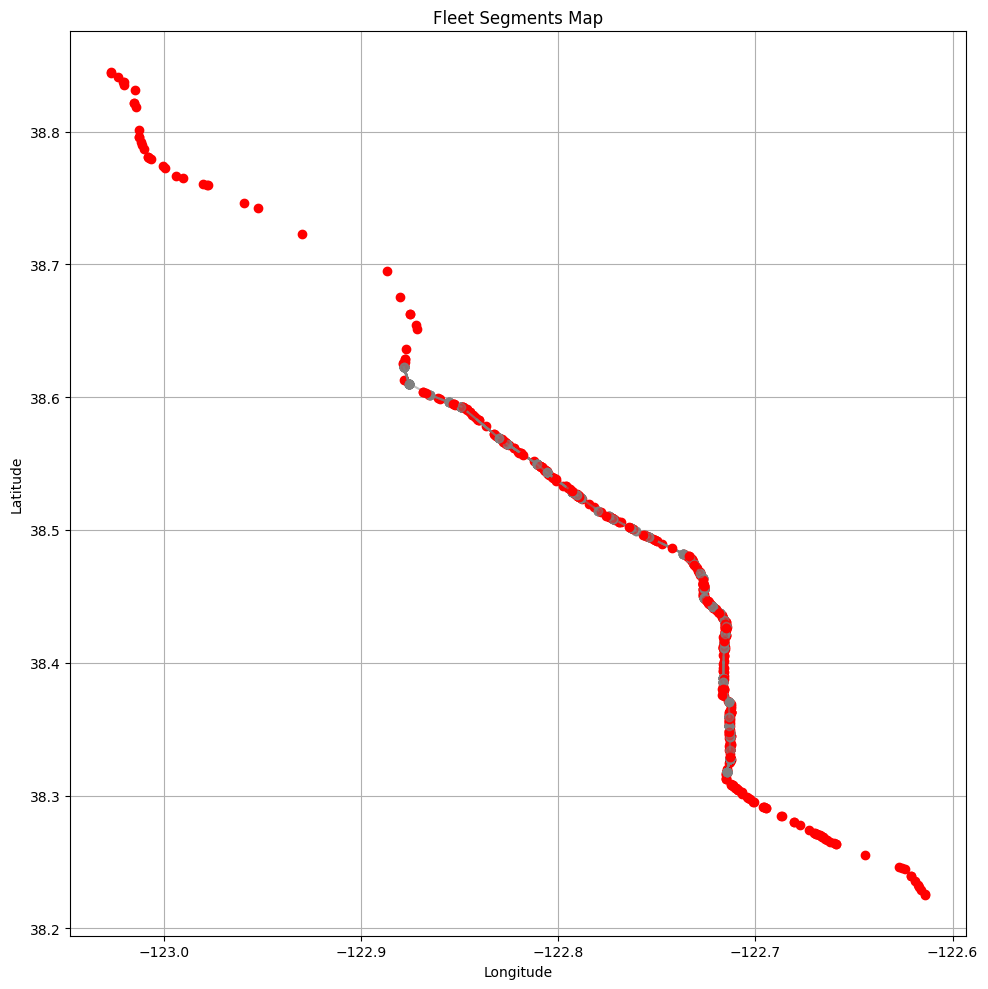

In [137]:
### plot each segment in fleet_lat_long_dict as a line on a map using matplotlib
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))
for key, segment in Entrance_filtered_dict.items():
    if segment is not None:    
        lon1 = ladris_lat_long_dict[segment][0][1]
        lat1 = ladris_lat_long_dict[segment][0][0]
        lon2 = ladris_lat_long_dict[segment][1][1]
        lat2 = ladris_lat_long_dict[segment][1][0]
        #ax.plot([lon1, lon2], [lat1, lat2], marker='o')
    ### Make all the lines and points gray
        ax.plot([lon1, lon2], [lat1, lat2], marker='o', color='gray', alpha=0.5)
        ### Plot the Entrance LAT LON as a red dot for each filtered_hw101[key][Entrance_LAT, Entrance_LON]
        ax.plot(filtered_hw101.loc[key]['Entrance_LON'], filtered_hw101.loc[key]['Entrance_LAT'], marker='o', color='red')

ax.set_title('Fleet Segments Map')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.grid()
plt.tight_layout()
plt.show()

In [59]:
ladris_hw101_segments

,GUID,Name,congestion_percentage_by_time,geometry,speed
415,28857931,Redwood Highway,"[[5355, 95], [10710, 98], [16065, 98], [21421,...","LINESTRING (-122.75417 38.49456, -122.74566 38...",59.0
645,28857930,Redwood Highway,"[[5355, 98], [10710, 98], [16065, 98], [21421,...","LINESTRING (-122.75673 38.4964, -122.7561 38.4...",59.0
693,28798888,Redwood Highway,"[[5355, 0], [10710, 0], [16065, 82], [21421, 0...","LINESTRING (-122.78694 38.52255, -122.78985 38...",59.0
1041,28836281,Redwood Highway,"[[5355, 26], [10710, 26], [16065, 32], [21421,...","LINESTRING (-122.87552 38.61014, -122.87607 38...",59.0
1480,28916791,Redwood Highway,"[[5355, 95], [10710, 98], [16065, 98], [21421,...","LINESTRING (-122.7161 38.41505, -122.71611 38....",59.0
2027,28892614,Redwood Highway,"[[5355, 49], [10710, 87], [16065, 88], [21421,...","LINESTRING (-122.71287 38.32789, -122.71287 38...",59.0
2187,28836283,Redwood Highway,"[[5355, 39], [10710, 71], [16065, 70], [21421,...","LINESTRING (-122.87578 38.61021, -122.87375 38...",59.0
2541,28884919,Redwood Highway,"[[5355, 52], [10710, 94], [16065, 87], [21421,...","LINESTRING (-122.71309 38.34436, -122.71297 38...",59.0
2743,28896726,Redwood Highway,"[[5355, 69], [10710, 98], [16065, 95], [21421,...","LINESTRING (-122.71296 38.33461, -122.71291 38...",59.0
3430,28795090,Redwood Highway,"[[5355, 95], [10710, 98], [16065, 98], [21421,...","LINESTRING (-122.72679 38.46413, -122.72667 38...",59.0


In [138]:
Exit_filtered_dict.keys()

dict_keys([121, 122, 124, 125, 126, 127, 128, 129, 130, 132, 133, 135, 136, 138, 139, 140, 141, 143, 144, 147, 148, 149, 150, 151, 153, 155, 157, 158, 159, 162, 165, 167, 169, 170, 172, 174, 175, 176, 179, 180, 181, 182, 184, 185, 186, 187, 189, 190, 192, 193, 195, 196, 197, 198, 200, 201, 202, 203, 206, 207, 208, 209, 210, 211, 212, 214, 215, 216, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 229, 230, 232, 233, 234, 235, 236, 238, 240, 241, 242, 244, 245, 246, 247, 248, 250, 251, 252, 254, 256, 260, 261, 262, 263, 265, 266, 267, 268, 270, 271, 272, 275, 277, 280, 281, 283, 284, 285, 287, 288, 291, 293, 294, 296, 301, 303, 304, 306, 307, 309, 310, 312, 313, 314, 316, 317, 318, 319, 320, 321, 323, 325, 329, 330, 331, 332, 333, 334, 335, 336, 338, 339, 341, 342, 345, 347, 349, 355, 356, 358, 359, 360, 361, 363, 364, 366, 367, 369, 371, 372, 373, 374, 375, 379, 380, 381, 382, 383, 385, 386, 387, 388, 389, 393, 394, 395, 396, 397, 398, 399, 400, 401, 403, 406, 408, 409, 410, 411, 412,

In [61]:
print(Exit_filtered_dict[120])
ladris_lat_long_dict[Exit_filtered_dict[120]]

28799549


[(38.5194296, -122.7840829), (38.5225535, -122.7869446)]

In [141]:
ladris_lat_long_dict

{28793424: [(38.5230097, -122.8074871), (38.5224304, -122.8075021)],
 28795004: [(38.4644662, -122.7243532), (38.4641175, -122.724355)],
 28894311: [(38.4157817, -122.7423096), (38.4159528, -122.7400192)],
 28918323: [(38.6229129, -122.8757745), (38.6237401, -122.8757817)],
 28796826: [(38.5157537, -122.7694732), (38.5155321, -122.7696255)],
 28864535: [(38.4509367, -122.8615641), (38.4506994, -122.8614671)],
 28797125: [(38.5132686, -122.7619619), (38.5132651, -122.7610383)],
 28855415: [(38.4993942, -122.7407099), (38.4993229, -122.740709)],
 28767171: [(38.448869, -122.6987822), (38.4489816, -122.6986581)],
 28906842: [(38.4282044, -122.7249972), (38.4280217, -122.7249784)],
 28860406: [(38.5083544, -122.9288002), (38.5089122, -122.925251)],
 28840069: [(38.4460287, -122.6954276), (38.4452387, -122.695162)],
 28793401: [(38.525571, -122.8101026), (38.5250185, -122.8134613)],
 28801139: [(38.5120034, -122.7797348), (38.5120036, -122.7795685)],
 28801918: [(38.4695869, -122.667137), (

In [140]:
# Dictionary to store consecutive segments for each trip
all_consecutive_segments = {}

# Process each southbound trip
for filtered in filtered_hw101_southbound.itertuples():
    index_label = filtered.Index
    
    # Skip if either entrance or exit wasn't mapped
    if index_label not in Entrance_filtered_dict or index_label not in Exit_filtered_dict:
        continue
    
    start_segment = Entrance_filtered_dict[index_label]
    end_segment = Exit_filtered_dict[index_label]
    
    # Skip if either is None
    if start_segment is None or end_segment is None:
        all_consecutive_segments[index_label] = None
        continue
    
    consecutive_segments = []
    consecutive_segments.append(start_segment)
    
    # Safety limit to prevent infinite loops
    MAX_SEGMENTS = 1000
    iterations = 0
    
    while consecutive_segments[-1] != end_segment and iterations < MAX_SEGMENTS:
        iterations += 1
        current_segment = consecutive_segments[-1]
        current_exit_latlon = ladris_lat_long_dict[current_segment][1]
        current_road = ladris_segment_roadNames[current_segment]
        
        found_next = False
        
        # Find the next segment whose entrance matches current segment's exit
        for segment in ladris_lat_long_dict:
            if (segment not in consecutive_segments and
                ladris_lat_long_dict[segment][0] == current_exit_latlon and 
                ladris_segment_roadNames[segment] == current_road):
                
                consecutive_segments.append(segment)
                found_next = True
                break
        
        if not found_next:
            # Could not find next segment - path is incomplete
            break
    
    # Store the result
    if consecutive_segments[-1] == end_segment:
        all_consecutive_segments[index_label] = consecutive_segments
    else:
        # Path didn't reach the end segment
        all_consecutive_segments[index_label] = None

# Summary statistics
total_trips = len(all_consecutive_segments)
successful_paths = sum(1 for v in all_consecutive_segments.values() if v is not None)
failed_paths = sum(1 for v in all_consecutive_segments.values() if v is None)

print(f"Total southbound trips processed: {total_trips}")
print(f"Successful paths found: {successful_paths}")
print(f"Failed to find complete path: {failed_paths}")

# Show some examples of successful paths
print("\nExample successful paths:")
count = 0
for index_label, segments in all_consecutive_segments.items():
    if segments is not None and count < 3:
        print(f"\nIndex {index_label}:")
        print(f"  Segments: {len(segments)}")
        print(f"  Path: {segments[:5]}{'...' if len(segments) > 5 else ''}")
        count += 1

# Show some examples of failed paths
print("\nExample failed paths:")
count = 0
for index_label, segments in all_consecutive_segments.items():
    if segments is None and count < 3:
        start_seg = Entrance_filtered_dict[index_label]
        end_seg = Exit_filtered_dict[index_label]
        print(f"\nIndex {index_label}:")
        print(f"  Start segment: {start_seg}")
        print(f"  End segment: {end_seg}")
        count += 1

Total southbound trips processed: 473
Successful paths found: 472
Failed to find complete path: 1

Example successful paths:

Index 121:
  Segments: 10
  Path: [28835052, 28855561, 28855562, 28799967, 28795090]...

Index 122:
  Segments: 18
  Path: [28782942, 28783981, 28784994, 28798892, 28799378]...

Index 124:
  Segments: 7
  Path: [28895425, 28895853, 28904760, 28884911, 28884919]...

Example failed paths:

Index 723:
  Start segment: 28782942
  End segment: 28782940


# all_consecutive_segments has:
- keys of index from Observed data 
- values as a list of consecuitive modeled segments

In [145]:
all_consecutive_segments.keys()

dict_keys([121, 122, 124, 125, 126, 127, 128, 129, 130, 132, 133, 135, 136, 138, 139, 140, 141, 143, 144, 147, 148, 149, 150, 151, 153, 155, 157, 158, 159, 162, 165, 167, 169, 170, 172, 174, 175, 176, 179, 180, 181, 182, 184, 185, 186, 187, 189, 190, 192, 193, 195, 196, 197, 198, 200, 201, 202, 203, 206, 207, 208, 209, 210, 211, 212, 214, 215, 216, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 229, 230, 232, 233, 234, 235, 236, 238, 240, 241, 242, 244, 245, 246, 247, 248, 250, 251, 252, 254, 256, 260, 261, 262, 263, 265, 266, 267, 268, 270, 271, 272, 275, 277, 280, 281, 283, 284, 285, 287, 288, 291, 293, 294, 296, 301, 303, 304, 306, 307, 309, 310, 312, 313, 314, 316, 317, 318, 319, 320, 321, 323, 325, 329, 330, 331, 332, 333, 334, 335, 336, 338, 339, 341, 342, 345, 347, 349, 355, 356, 358, 359, 360, 361, 363, 364, 366, 367, 369, 371, 372, 373, 374, 375, 379, 380, 381, 382, 383, 385, 386, 387, 388, 389, 393, 394, 395, 396, 397, 398, 399, 400, 401, 403, 406, 408, 409, 410, 411, 412,

In [146]:
for s in all_consecutive_segments[121]:
    print(ladris_segment_roadNames[s])

Redwood Highway
Redwood Highway
Redwood Highway
Redwood Highway
Redwood Highway
Redwood Highway
Redwood Highway
Redwood Highway
Redwood Highway
Redwood Highway


In [ ]:
print(ladris_segment_roadNames[start_segment], ladris_segment_roadNames[end_segment])
print(ladris_lat_long_dict[segment][0], ladris_lat_long_dict[consecutive_segments[-1]][1])
print(ladris_lat_long_dict[end_segment][0], ladris_lat_long_dict[end_segment][1])
consecutive_segments

Redwood Highway Redwood Highway
(38.5578532, -122.8331459) (38.3177853, -122.7146081)
(38.5194296, -122.7840829) (38.5225535, -122.7869446)


[28780003,
 28780001,
 28780769,
 28769856,
 28770235,
 28770044,
 28781391,
 28916791,
 28884343,
 28884259,
 28884102,
 28895425,
 28895853,
 28904760,
 28884911,
 28884919,
 28896726,
 28892614]

In [ ]:
print(ladris_lat_long_dict[segment][0])
print(ladris_lat_long_dict[consecutive_segments[-1]][1])
print(ladris_segment_roadNames[segment])

(38.4422044, -122.7215877)
(38.4422044, -122.7215877)
Redwood Highway


In [147]:
example_times = ladris_congestion[28857930]
### convert example_times to hours
example_times = [[int(time[0] / 6759), time[1]] for time in example_times]
example_times

[[0, 98],
 [1, 98],
 [2, 98],
 [3, 98],
 [3, 98],
 [4, 98],
 [5, 98],
 [6, 98],
 [7, 98],
 [7, 98],
 [8, 98],
 [9, 98],
 [10, 98],
 [11, 98],
 [11, 0],
 [12, 0],
 [13, 0],
 [14, 0],
 [15, 0],
 [15, 0],
 [16, 0],
 [17, 0],
 [18, 0],
 [19, 0],
 [19, 0]]

In [148]:
len(example_times)

25

In [149]:
### print first 5 values of fleet_speed_hw101
ladris_speed_hw101.keys()

dict_keys([28857931, 28857930, 28798888, 28836281, 28916791, 28892614, 28836283, 28884919, 28896726, 28795090, 28800206, 28799967, 28919550, 28798891, 28798892, 28838193, 28780003, 28780769, 28799378, 28798890, 28884911, 28781391, 28895853, 28780001, 28846299, 28874256, 28784994, 28784932, 28782942, 28827199, 28770235, 28846331, 28884343, 28783981, 28857928, 28855562, 28799549, 28884259, 28904760, 28799329, 28884102, 28770044, 28783980, 28801154, 28835052, 28769856, 28782940, 28801101, 28895425, 28855561])

In [150]:
print(len(ladris_speed_hw101), len(ladris_speed_hw116), len(ladris_speed_hw12))

50 79 13


# Calculate the simulated speeds per road segment of hw101 per time segment in hours from Ladris

In [151]:
ladrisInterpolation = 93

In [152]:
hw101_ladris_speed_congestion = {}
for seg_id in ladris_speed_hw101.keys():
    #seg_id = 28857930

    example_times = ladris_congestion[seg_id]
    ### convert example_times to hours
    #example_times = [[int(time[0] / 6759), time[1]] for time in example_times]
    ### set example_times as the integer count from 1 to the length of
    example_times = [[i + 1, time[1]] for i, time in enumerate(example_times)]

    ### example_times is a list of lists where each list is two values a time interval and a congestion level per time interval for seg_id which is a segment ID on hw101
    ### ladris_speed_hw101 is a dictionary that has the speed limit data for all segments on hw101 where the key is the segment ID and the value is the speed limit
    ### create a new example_congestion that computes for each time segment speed = speed limit * (1 - congestion level / 100)
    example_congestion = []
    timeCounts = 1
    for time in example_times:
        time_interval = round((time[0]*ladrisInterpolation)/60)
        congestion_level = time[1]
        speed_limit = ladris_speed_hw101[seg_id]
        speed = speed_limit * (1 - congestion_level / 100)
        if time_interval > timeCounts:
            example_congestion.append((timeCounts, speed))
            timeCounts += 1
        example_congestion.append((time_interval, speed))
        timeCounts += 1
    hw101_ladris_speed_congestion[seg_id] = example_congestion

len(hw101_ladris_speed_congestion)



50

In [153]:
#ladris_speed_hw116

hw116_ladris_speed_congestion = {}
for seg_id in ladris_speed_hw116.keys():
    #seg_id = 28857930

    example_times = ladris_congestion[seg_id]
    ### convert example_times to hours
    #example_times = [[int(time[0] / 6759), time[1]] for time in example_times]
    example_times = [[i + 1, time[1]] for i, time in enumerate(example_times)]

    ### example_times is a list of lists where each list is two values a time interval and a congestion level per time interval for seg_id which is a segment ID on hw101
    ### ladris_speed_hw101 is a dictionary that has the speed limit data for all segments on hw101 where the key is the segment ID and the value is the speed limit
    ### create a new example_congestion that computes for each time segment speed = speed limit * (1 - congestion level / 100)
    example_congestion = []
    timeCounts = 1
    for time in example_times:
        time_interval = round((time[0]*ladrisInterpolation)/60) 
        congestion_level = time[1]
        speed_limit = ladris_speed_hw116[seg_id]
        speed = speed_limit * (1 - congestion_level / 100)
        if time_interval > timeCounts:
            example_congestion.append((timeCounts, speed))
            timeCounts += 1
        example_congestion.append((time_interval, speed))
        timeCounts += 1
    hw116_ladris_speed_congestion[seg_id] = example_congestion

len(hw116_ladris_speed_congestion)

79

In [154]:
example_congestion

[(1, 49.0),
 (2, 49.0),
 (3, 49.0),
 (4, 49.0),
 (5, 49.0),
 (6, 49.0),
 (7, 49.0),
 (8, 49.0),
 (9, 49.0),
 (10, 49.0),
 (11, 49.0),
 (12, 1.4700000000000013),
 (13, 1.4700000000000013),
 (14, 1.4700000000000013),
 (15, 1.4700000000000013),
 (16, 1.4700000000000013),
 (17, 1.4700000000000013),
 (18, 1.4700000000000013),
 (19, 1.4700000000000013),
 (20, 1.4700000000000013),
 (21, 1.4700000000000013),
 (22, 1.4700000000000013),
 (23, 1.4700000000000013),
 (24, 1.4700000000000013),
 (25, 1.4700000000000013),
 (26, 1.4700000000000013),
 (27, 1.4700000000000013),
 (28, 1.4700000000000013),
 (29, 1.4700000000000013),
 (30, 1.4700000000000013),
 (31, 1.4700000000000013),
 (32, 1.4700000000000013),
 (33, 1.4700000000000013),
 (34, 49.0),
 (35, 49.0),
 (36, 49.0),
 (37, 49.0),
 (38, 49.0),
 (39, 49.0)]

In [155]:
#ladris_speed_hw12

hw12_ladris_speed_congestion = {}
for seg_id in ladris_speed_hw12.keys():
    #seg_id = 28857930

    example_times = ladris_congestion[seg_id]
    ### convert example_times to hours
    #example_times = [[int(time[0] / 6759), time[1]] for time in example_times]
    example_times = [[i + 1, time[1]] for i, time in enumerate(example_times)]

    ### example_times is a list of lists where each list is two values a time interval and a congestion level per time interval for seg_id which is a segment ID on hw101
    ### ladris_speed_hw101 is a dictionary that has the speed limit data for all segments on hw101 where the key is the segment ID and the value is the speed limit
    ### create a new example_congestion that computes for each time segment speed = speed limit * (1 - congestion level / 100)
    example_congestion = []
    timeCounts = 1
    for time in example_times:
        time_interval = round((time[0]*ladrisInterpolation)/60)
        congestion_level = time[1]
        speed_limit = ladris_speed_hw12[seg_id]
        speed = speed_limit * (1 - congestion_level / 100)
        if time_interval > timeCounts:
            example_congestion.append((timeCounts, speed))
            timeCounts += 1
        example_congestion.append((time_interval, speed))
        timeCounts += 1
    hw12_ladris_speed_congestion[seg_id] = example_congestion

len(hw12_ladris_speed_congestion)

13

In [156]:
example_congestion

[(1, 59.0),
 (2, 59.0),
 (3, 59.0),
 (4, 59.0),
 (5, 59.0),
 (6, 59.0),
 (7, 59.0),
 (8, 59.0),
 (9, 59.0),
 (10, 59.0),
 (11, 59.0),
 (12, 59.0),
 (13, 59.0),
 (14, 59.0),
 (15, 59.0),
 (16, 59.0),
 (17, 59.0),
 (18, 59.0),
 (19, 59.0),
 (20, 17.110000000000003),
 (21, 8.260000000000002),
 (22, 8.260000000000002),
 (23, 8.260000000000002),
 (24, 5.309999999999998),
 (25, 5.309999999999998),
 (26, 4.719999999999998),
 (27, 2.950000000000003),
 (28, 2.950000000000003),
 (29, 3.540000000000003),
 (30, 8.260000000000002),
 (31, 8.260000000000002),
 (32, 59.0),
 (33, 59.0),
 (34, 59.0),
 (35, 59.0),
 (36, 59.0),
 (37, 59.0),
 (38, 59.0),
 (39, 59.0)]

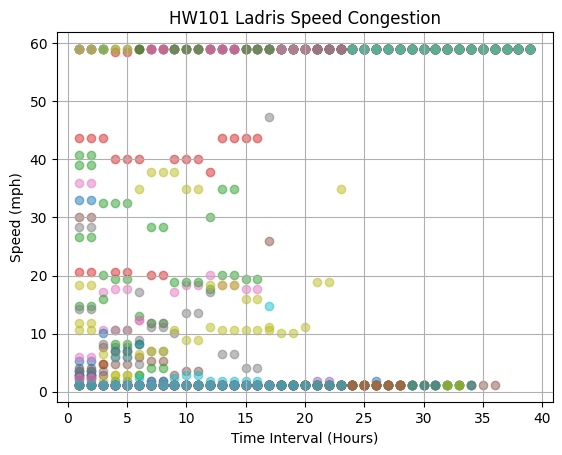

In [157]:
### Plot hw101_ladris_speed_congestion for all segments as scatter plot
for seg_id in hw101_ladris_speed_congestion.keys():
    times = [time[0] for time in hw101_ladris_speed_congestion[seg_id]]
    speeds = [time[1] for time in hw101_ladris_speed_congestion[seg_id]]
    plt.scatter(times, speeds, label=f'Segment {seg_id}', alpha=0.5)
plt.title('HW101 Ladris Speed Congestion')
plt.xlabel('Time Interval (Hours)')
plt.ylabel('Speed (mph)')
#plt.legend()
plt.grid()
plt.show()

In [158]:
for k in hw101_ladris_speed_congestion.keys():
    print(k, hw101_ladris_speed_congestion[k])

28857931 [(1, 2.950000000000003), (2, 2.950000000000003), (3, 1.180000000000001), (4, 1.180000000000001), (5, 1.180000000000001), (6, 1.180000000000001), (7, 1.180000000000001), (8, 1.180000000000001), (9, 1.180000000000001), (10, 1.180000000000001), (11, 1.180000000000001), (12, 1.180000000000001), (13, 1.180000000000001), (14, 1.180000000000001), (15, 1.180000000000001), (16, 1.180000000000001), (17, 1.180000000000001), (18, 1.180000000000001), (19, 1.180000000000001), (20, 1.180000000000001), (21, 1.180000000000001), (22, 1.180000000000001), (23, 1.180000000000001), (24, 59.0), (25, 59.0), (26, 59.0), (27, 59.0), (28, 59.0), (29, 59.0), (30, 59.0), (31, 59.0), (32, 59.0), (33, 59.0), (34, 59.0), (35, 59.0), (36, 59.0), (37, 59.0), (38, 59.0), (39, 59.0)]
28857930 [(1, 1.180000000000001), (2, 1.180000000000001), (3, 1.180000000000001), (4, 1.180000000000001), (5, 1.180000000000001), (6, 1.180000000000001), (7, 1.180000000000001), (8, 1.180000000000001), (9, 1.180000000000001), (10, 1

In [159]:
len(hw101_ladris_speed_congestion)

50

In [160]:
# hw101_ladris_speed_congestion[28782942]
### compute the average speed for each hour based on speed values from ladris_speed_congestion
### set hour_sum to be a list of 25 zeros

h101_total_count = len(hw101_ladris_speed_congestion)
hw101_hour_sum = [0] * h101_total_count
hw101_hour_avg = [0] * h101_total_count
hw101_hour_min = [60] * h101_total_count
for k in hw101_ladris_speed_congestion.keys():
    for time in hw101_ladris_speed_congestion[k]:
        hour = time[0]
        speed = time[1]
        hw101_hour_sum[hour-1] += speed
        if speed < hw101_hour_min[hour-1]:
            hw101_hour_min[hour-1] = speed
for i in range(h101_total_count):
    hw101_hour_avg[i] = hw101_hour_sum[i] / h101_total_count

hw101_hour_min

[1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 59.0,
 59.0,
 59.0,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60]

In [161]:
hw101_hour_avg

[15.741199999999987,
 15.741199999999987,
 10.407600000000002,
 8.472400000000002,
 8.472400000000002,
 10.218800000000003,
 9.640600000000003,
 9.640600000000003,
 11.882599999999998,
 11.906199999999997,
 11.906199999999997,
 11.009399999999996,
 11.009399999999996,
 11.009399999999996,
 11.375199999999998,
 11.375199999999998,
 14.820799999999986,
 18.702999999999985,
 18.702999999999985,
 22.195799999999995,
 25.8302,
 25.8302,
 30.762600000000003,
 34.7156,
 34.7156,
 38.196600000000004,
 42.81040000000001,
 42.81040000000001,
 48.5924,
 49.7488,
 49.7488,
 52.0616,
 52.0616,
 54.374399999999994,
 57.84360000000001,
 57.84360000000001,
 59.0,
 59.0,
 59.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [162]:
len(hw101_hour_min)

50

In [163]:
#hw101_ladris_speed_congestion[28782942]
hw101_hour_avg

[15.741199999999987,
 15.741199999999987,
 10.407600000000002,
 8.472400000000002,
 8.472400000000002,
 10.218800000000003,
 9.640600000000003,
 9.640600000000003,
 11.882599999999998,
 11.906199999999997,
 11.906199999999997,
 11.009399999999996,
 11.009399999999996,
 11.009399999999996,
 11.375199999999998,
 11.375199999999998,
 14.820799999999986,
 18.702999999999985,
 18.702999999999985,
 22.195799999999995,
 25.8302,
 25.8302,
 30.762600000000003,
 34.7156,
 34.7156,
 38.196600000000004,
 42.81040000000001,
 42.81040000000001,
 48.5924,
 49.7488,
 49.7488,
 52.0616,
 52.0616,
 54.374399999999994,
 57.84360000000001,
 57.84360000000001,
 59.0,
 59.0,
 59.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

# we now have list of average speeds per time with hw101_ladris_speed_congestion[28782942]

In [164]:
### compute the average speed for each hour based on speed values from ladris_speed_congestion
### set hour_sum to be a list of 25 zeros
hw116_hour_sum = [0] * h101_total_count
h116_total_count = len(hw116_ladris_speed_congestion)
hw116_hour_avg = [0] * h101_total_count
hw116_hour_min = [60] * h101_total_count
for k in hw116_ladris_speed_congestion.keys():
    for time in hw116_ladris_speed_congestion[k]:
        hour = time[0]
        speed = time[1]
        hw116_hour_sum[hour-1] += speed
        if speed < hw116_hour_min[hour-1]:
            hw116_hour_min[hour-1] = speed
for i in range(h101_total_count):
    hw116_hour_avg[i] = hw116_hour_sum[i] / h116_total_count

hw116_hour_min

[49.0,
 49.0,
 49.0,
 49.0,
 49.0,
 49.0,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 1.4700000000000013,
 49.0,
 49.0,
 49.0,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60]

In [165]:
### compute the average speed for each hour based on speed values from ladris_speed_congestion
### set hour_sum to be a list of 25 zeros
hw12_hour_sum = [0] * h101_total_count
h12_total_count = len(hw12_ladris_speed_congestion)
hw12_hour_avg = [0] * h101_total_count
hw12_hour_min = [60] * h101_total_count
for k in hw12_ladris_speed_congestion.keys():
    for time in hw12_ladris_speed_congestion[k]:
        hour = time[0]
        speed = time[1]
        hw12_hour_sum[hour-1] += speed
        if speed < hw12_hour_min[hour-1]:
            hw12_hour_min[hour-1] = speed
for i in range(h101_total_count):
    hw12_hour_avg[i] = hw12_hour_sum[i] / h12_total_count

hw12_hour_min

[59.0,
 59.0,
 59.0,
 1.7700000000000016,
 1.7700000000000016,
 1.7700000000000016,
 12.389999999999997,
 12.389999999999997,
 14.75,
 1.7700000000000016,
 1.7700000000000016,
 1.180000000000001,
 1.7700000000000016,
 1.7700000000000016,
 1.180000000000001,
 1.180000000000001,
 1.7700000000000016,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.180000000000001,
 1.7700000000000016,
 1.7700000000000016,
 59.0,
 59.0,
 59.0,
 59.0,
 59.0,
 59.0,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60,
 60]

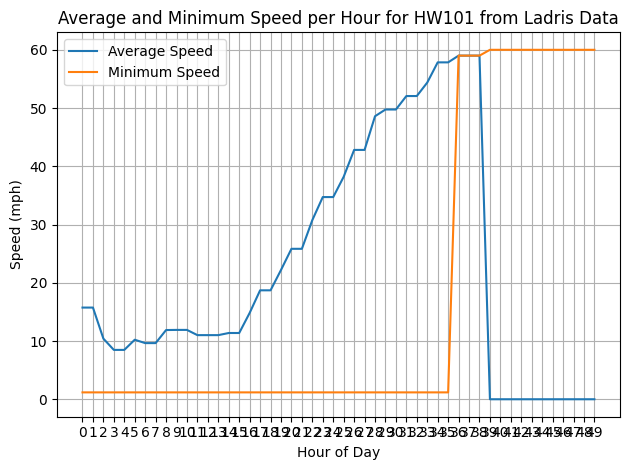

In [166]:
### Plot hour_avg as a line plot with x axis as hours from 0 to 24 and y axis as average speed also plot hour_min as a line plot with x axis as hours from 0 to 24 and y axis as minimum speed
plt.plot(range(50), hw101_hour_avg, label='Average Speed')
plt.plot(range(50), hw101_hour_min, label='Minimum Speed')
plt.title('Average and Minimum Speed per Hour for HW101 from Ladris Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
plt.xticks(range(50))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [167]:
print(len(hw116_hour_avg), len(hw101_hour_avg), len(hw12_hour_avg))

50 50 50


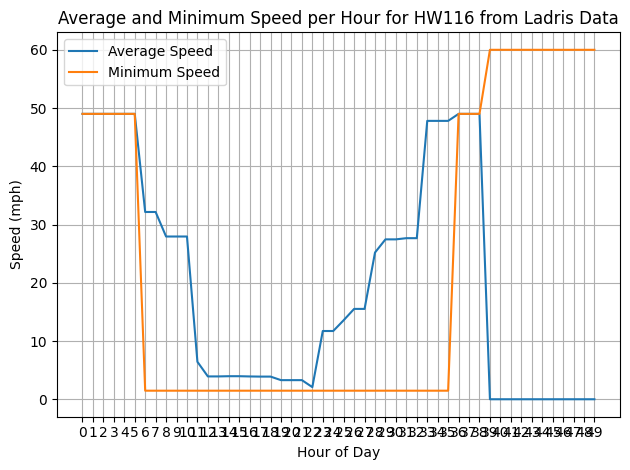

In [168]:
### Plot hour_avg as a line plot with x axis as hours from 0 to 24 and y axis as average speed also plot hour_min as a line plot with x axis as hours from 0 to 24 and y axis as minimum speed
plt.plot(range(50), hw116_hour_avg, label='Average Speed')
plt.plot(range(50), hw116_hour_min, label='Minimum Speed')
plt.title('Average and Minimum Speed per Hour for HW116 from Ladris Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
plt.xticks(range(50))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

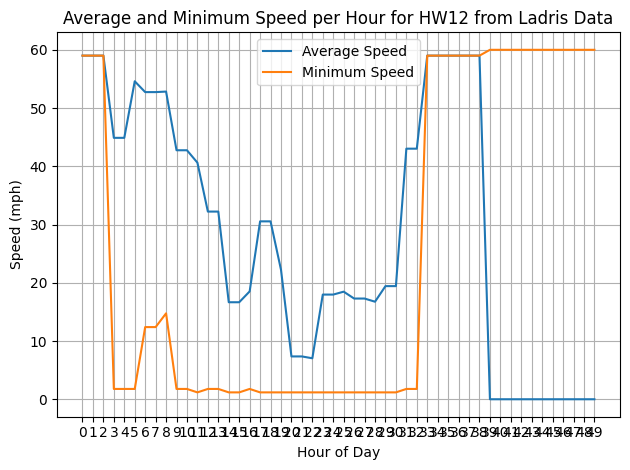

In [169]:
### Plot hour_avg as a line plot with x axis as hours from 0 to 24 and y axis as average speed also plot hour_min as a line plot with x axis as hours from 0 to 24 and y axis as minimum speed
plt.plot(range(50), hw12_hour_avg, label='Average Speed')
plt.plot(range(50), hw12_hour_min, label='Minimum Speed')
plt.title('Average and Minimum Speed per Hour for HW12 from Ladris Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
plt.xticks(range(50))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [170]:
total_filtered_data

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
0,User37,38.307287,-122.478139,2019-10-26 17:37:00,38.294198,-122.475950,2019-10-26 17:58:00,Hwy 12,Hwy 12,21.0,0.912118,2.606051,2019-10-26,2019-10-26 17:00:00
1,User98,38.319046,-122.485520,2019-10-26 20:25:00,38.302395,-122.475478,2019-10-26 20:35:00,Hwy 12,Hwy 12,10.0,1.272787,7.636719,2019-10-26,2019-10-26 20:00:00
2,User108,38.343465,-122.497494,2019-10-26 01:36:00,38.458950,-122.673962,2019-10-26 01:55:00,Hwy 12,Hwy 12,19.0,12.448713,39.311727,2019-10-26,2019-10-26 01:00:00
3,User108,38.449852,-122.683446,2019-10-26 05:12:00,38.392817,-122.530753,2019-10-26 05:26:00,Hwy 12,Hwy 12,14.0,9.156916,39.243925,2019-10-26,2019-10-26 05:00:00
4,User108,38.305785,-122.477710,2019-10-26 23:14:00,38.355610,-122.502558,2019-10-26 23:32:00,Hwy 12,Hwy 12,18.0,3.696630,12.322099,2019-10-26,2019-10-26 23:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,User2028,38.392002,-122.817728,2019-10-26 03:15:00,38.468563,-122.884547,2019-10-26 03:26:00,Hwy 116,Hwy 116,11.0,6.407988,34.952660,2019-10-26,2019-10-26 03:00:00
872,User2156,38.389170,-122.815711,2019-10-26 00:32:00,38.412086,-122.842662,2019-10-26 00:43:00,Hwy 116,Hwy 116,11.0,2.153280,11.745163,2019-10-26,2019-10-26 00:00:00
873,User2170,38.345782,-122.759535,2019-10-26 21:35:00,38.334367,-122.736961,2019-10-26 23:13:00,Hwy 116,Hwy 116,98.0,1.455552,0.891154,2019-10-26,2019-10-26 21:00:00
874,User2321,38.415091,-122.845280,2019-10-26 23:33:00,38.340804,-122.753055,2019-10-26 23:48:00,Hwy 116,Hwy 116,15.0,7.162274,28.649095,2019-10-26,2019-10-26 23:00:00


In [171]:
### Redwood is 101
### CA 12 is 12
### Gravenstein is 116

### Reduce unique_highways to only 'Hwy 12', 'Hwy 101', and 'Hwy 116'
#unique_highways = ['Hwy 12', 'Hwy 101', 'Hwy 116']

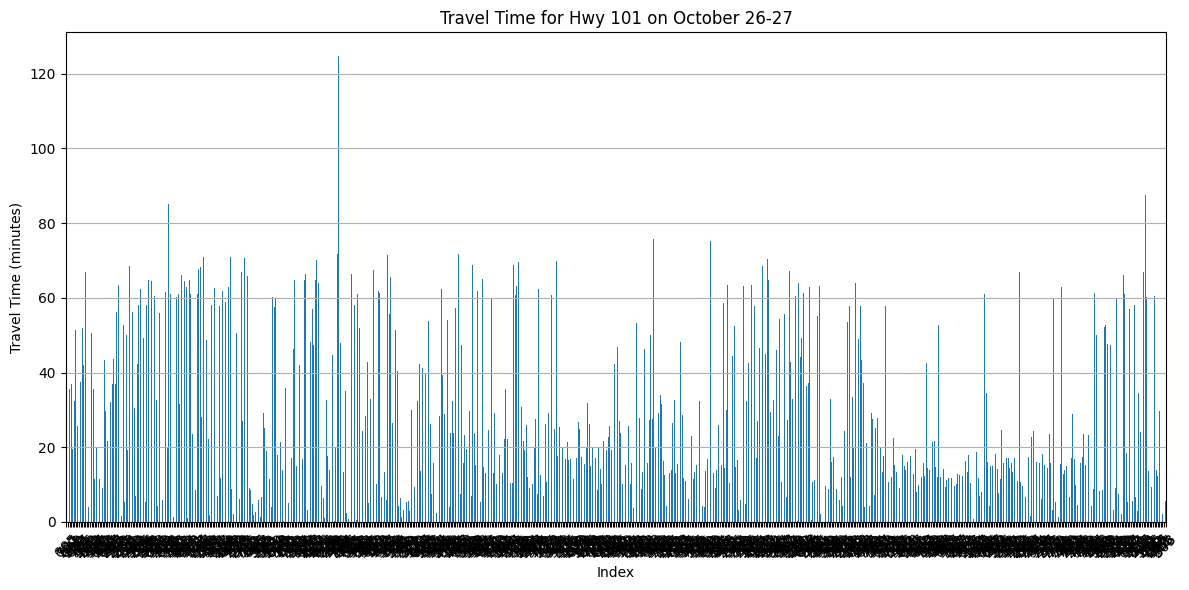

In [172]:

### plot total_filtered_data where Entrance_HWY is 'Hwy 101' sorted by Entrance_TIMESTAMP
kinkade_tt_list = total_filtered_data[total_filtered_data['Entrance_HWY'] == 'Hwy 101'].sort_values(by='Entrance_TIMESTAMP')['Avg_Speed']

### plot bar plot of kinkade_tt_list
kinkade_tt_list.plot(kind='bar', figsize=(12, 6))
plt.title('Travel Time for Hwy 101 on October 26-27')
plt.xlabel('Index')
plt.ylabel('Travel Time (minutes)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



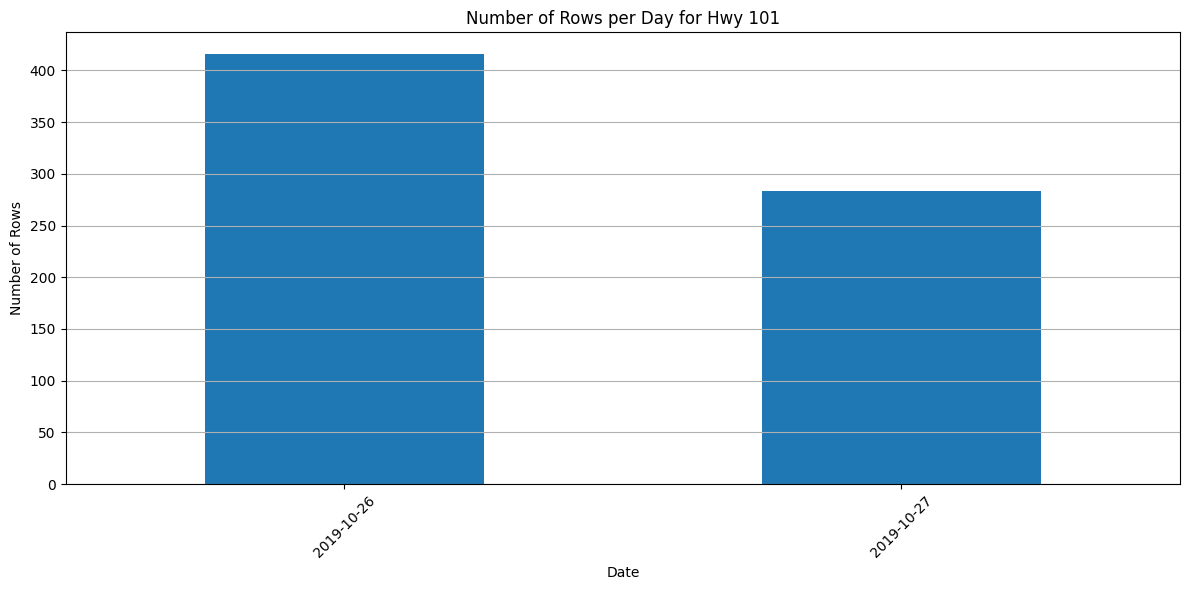

In [173]:
### create a histogram by date for total_filtered_data where Entrance_HWY is 'Hwy 101'
total_filtered_data[total_filtered_data['Entrance_HWY'] == 'Hwy 101']['Entrance_TIMESTAMP'].dt.date.value_counts().sort_index().plot(kind='bar', figsize=(12, 6))
plt.title('Number of Rows per Day for Hwy 101')
plt.xlabel('Date')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [174]:
### give summary stats for total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]['Travel_Time']
hw101_dists = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]['Distance'].describe()
hw116_dists = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116')]['Travel_Time'].describe()
hw12_dists = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12')]['Travel_Time'].describe()

In [175]:
hw101_dists

count    699.000000
mean      10.834474
std        7.679627
min        0.370975
25%        5.087535
50%        9.767993
75%       14.155400
max       46.780909
Name: Distance, dtype: float64

# Filters to get different collections of data based on distance bins

In [176]:
### get total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]['Distance'] that are less than hw101_dists['25%']
#total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%'])]

### print total_filtered_data[total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26')] where Entrance_Hwy is 'Hwy 101' and Exit_Hwy is 'Hwy 101'
#total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]


### get total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101')]['Distance'] that are less than hw101_dists['50%'] and greater than hw101_dists['25%']
#total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['max']) & (total_filtered_data['Distance'] >= hw101_dists['75%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]

#total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]

# Now get the average speed per hour for main evacuation Routes

In [177]:
ranges = ['25%', '50%', '75%', 'max', 'all']
### create a list of average speeds for each hour of total_filtered_data[total_filtered_data['Entrance_HWY'] == 'Hwy 101'].sort_values(by='Entrance_TIMESTAMP')['Avg_Speed']
speed_hw101_bins = {}
speed_hw101_avg_list = []

hw101_total_mean = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]['Avg_Speed'].mean()
for hour in range(48):  # 48 hours from Oct 26 00:00 to Oct 27 23:59
    hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]        
    if not hourly_data.empty:
        avg_speed = hourly_data['Avg_Speed'].mean()
    else:
        avg_speed = hw101_total_mean
    speed_hw101_avg_list.append(avg_speed)  
for r in ranges:
    speed_hw101_bins[r] = []    
    if r == '25%':
        #hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
        ### get hourly_data for distances are less than hw101_dists
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)
    elif r == '50%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['50%']) & (total_filtered_data['Distance'] >= hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)
    elif r == '75%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['75%']) & (total_filtered_data['Distance'] >= hw101_dists['50%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)
    elif r == 'max':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['max']) & (total_filtered_data['Distance'] >= hw101_dists['75%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)
    elif r == 'all':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw101_bins[r].append(avg_speed)


### do the same for Hwy 116
speed_hw116_bins = {}
speed_hw116_avg_list = []
hw116_total_mean = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]['Avg_Speed'].mean()
for hour in range(48):  # 48 hours from Oct 26 00:00 to Oct 27 23:59
    hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
    if not hourly_data.empty:
        avg_speed = hourly_data['Avg_Speed'].mean()
    else:
        avg_speed = hw116_total_mean
    speed_hw116_avg_list.append(avg_speed)    
#speed_hw116_avg_list
for r in ranges:
    speed_hw116_bins[r] = []    
    if r == '25%':
        #hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
        ### get hourly_data for distances are less than hw101_dists
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)
    elif r == '50%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Distance'] < hw101_dists['50%']) & (total_filtered_data['Distance'] >= hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)
    elif r == '75%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Distance'] < hw101_dists['75%']) & (total_filtered_data['Distance'] >= hw101_dists['50%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)
    elif r == 'max':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Distance'] < hw101_dists['max']) & (total_filtered_data['Distance'] >= hw101_dists['75%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)
    elif r == 'all':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 116') & (total_filtered_data['Exit_HWY'] == 'Hwy 116') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw116_bins[r].append(avg_speed)

### do the same for Hwy 12
speed_hw12_bins = {}
speed_hw12_avg_list = []
hw12_total_mean = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]['Avg_Speed'].mean()
for hour in range(48):  # 48 hours from Oct 26 00:00 to Oct 27 23:59
    hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
    if not hourly_data.empty:
        avg_speed = hourly_data['Avg_Speed'].mean()
    else:
        avg_speed = hw12_total_mean
    speed_hw12_avg_list.append(avg_speed)    
for r in ranges:
    speed_hw12_bins[r] = []    
    if r == '25%':
        #hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 101') & (total_filtered_data['Exit_HWY'] == 'Hwy 101') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26') + pd.Timedelta(hours=hour))]
        ### get hourly_data for distances are less than hw101_dists
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Distance'] < hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
    elif r == '50%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Distance'] < hw101_dists['50%']) & (total_filtered_data['Distance'] >= hw101_dists['25%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
    elif r == '75%':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Distance'] < hw101_dists['75%']) & (total_filtered_data['Distance'] >= hw101_dists['50%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
    elif r == 'max':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Distance'] < hw101_dists['max']) & (total_filtered_data['Distance'] >= hw101_dists['75%']) & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
    elif r == 'all':
        hourly_data = total_filtered_data[(total_filtered_data['Entrance_HWY'] == 'Hwy 12') & (total_filtered_data['Exit_HWY'] == 'Hwy 12') & (total_filtered_data['Entrance_TIMESTAMP'].dt.floor('H') == pd.Timestamp('2019-10-26'))]
        if not hourly_data.empty:
            avg_speed = hourly_data#['Avg_Speed']#.mean()
        #else:
            #avg_speed = 0
        speed_hw12_bins[r].append(avg_speed)
#speed_hw12_avg_list

In [178]:
speed_hw101_bins['all'][0]

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
151,User110,38.343079,-122.713015,2019-10-26 00:12:00,38.191072,-122.601263,2019-10-26 00:26:00,Hwy 101,Hwy 101,14.0,12.126700,51.971570,2019-10-26,2019-10-26
182,User230,38.489677,-122.747218,2019-10-26 00:25:00,38.248493,-122.631175,2019-10-26 00:55:00,Hwy 101,Hwy 101,30.0,17.810430,35.620859,2019-10-26,2019-10-26
210,User347,38.339388,-122.713015,2019-10-26 00:18:00,38.235704,-122.619545,2019-10-26 00:30:00,Hwy 101,Hwy 101,12.0,8.775906,43.879530,2019-10-26,2019-10-26
212,User353,38.525812,-122.790391,2019-10-26 00:23:00,38.405821,-122.716491,2019-10-26 00:38:00,Hwy 101,Hwy 101,15.0,9.204169,36.816675,2019-10-26,2019-10-26
247,User456,38.790085,-123.011276,2019-10-26 00:48:00,38.427021,-122.714688,2019-10-26 01:29:00,Hwy 101,Hwy 101,41.0,29.760572,43.552057,2019-10-26,2019-10-26
253,User489,38.214762,-122.603194,2019-10-26 00:37:00,38.290507,-122.694647,2019-10-26 00:47:00,Hwy 101,Hwy 101,10.0,7.211892,43.271352,2019-10-26,2019-10-26
280,User567,38.834974,-123.020203,2019-10-26 00:47:00,38.369042,-122.712843,2019-10-26 01:46:00,Hwy 101,Hwy 101,59.0,36.218889,36.832769,2019-10-26,2019-10-26
299,User603,38.201844,-122.598516,2019-10-26 00:59:00,38.247163,-122.627570,2019-10-26 01:10:00,Hwy 101,Hwy 101,11.0,3.505948,19.123355,2019-10-26,2019-10-26
341,User736,38.531563,-122.795197,2019-10-26 00:59:00,38.515169,-122.780263,2019-10-26 01:55:00,Hwy 101,Hwy 101,56.0,1.390942,1.490295,2019-10-26,2019-10-26
380,User885,38.414447,-122.716147,2019-10-26 00:05:00,38.243730,-122.623493,2019-10-26 00:20:00,Hwy 101,Hwy 101,15.0,12.819959,51.279837,2019-10-26,2019-10-26


In [179]:
### For 101 25% is under 5 miles, 50% is 5-10 miles, 75% is 10-15 miles, max is 15+ miles
### For 116 25% is under 3 miles, 50% is 3-10 miles, 75% is 5-10 miles, max is 5+ miles
### For 12 25% is under 3 miles, 50% is 6-7 miles, 75% is 10+ miles, max is 10+ miles
print(len(speed_hw12_bins['25%']))
speed_hw12_bins['25%'][0]



1


,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
15,User444,38.431742,-122.706792,2019-10-26 00:35:00,38.45865,-122.674648,2019-10-26 00:46:00,Hwy 12,Hwy 12,11.0,2.546007,13.887308,2019-10-26,2019-10-26
114,User2381,38.431184,-122.708723,2019-10-26 00:34:00,38.45822,-122.675421,2019-10-26 00:45:00,Hwy 12,Hwy 12,11.0,2.595590,14.157761,2019-10-26,2019-10-26


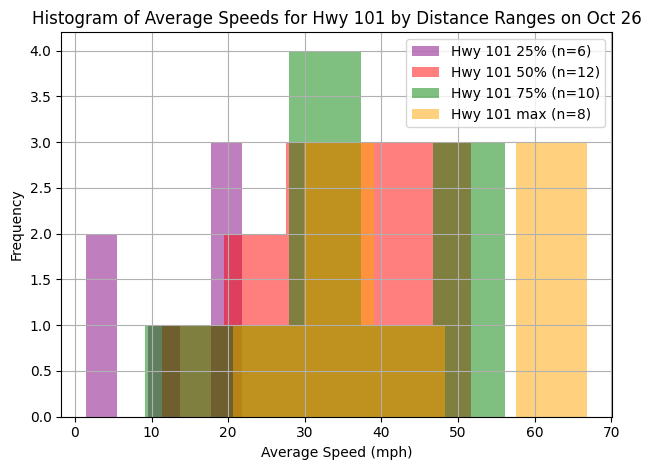

In [180]:
### plot a histogram for each speed_hw101_bins[r][0]['Avg_Speed'] for r in ranges on the same plot with different colors and a legend
for r in ranges:
    #if r == 'all':
    #    plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='blue')
    if r == 'max':
        plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='orange')
    elif r == '75%':
        plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='green')
    elif r == '50%':
        plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='red')
    elif r == '25%':
        plt.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.5, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='purple')
plt.title('Histogram of Average Speeds for Hwy 101 by Distance Ranges on Oct 26')
plt.xlabel('Average Speed (mph)')
plt.ylabel('Frequency')
plt.legend()
plt.grid()  
plt.tight_layout()
plt.show()

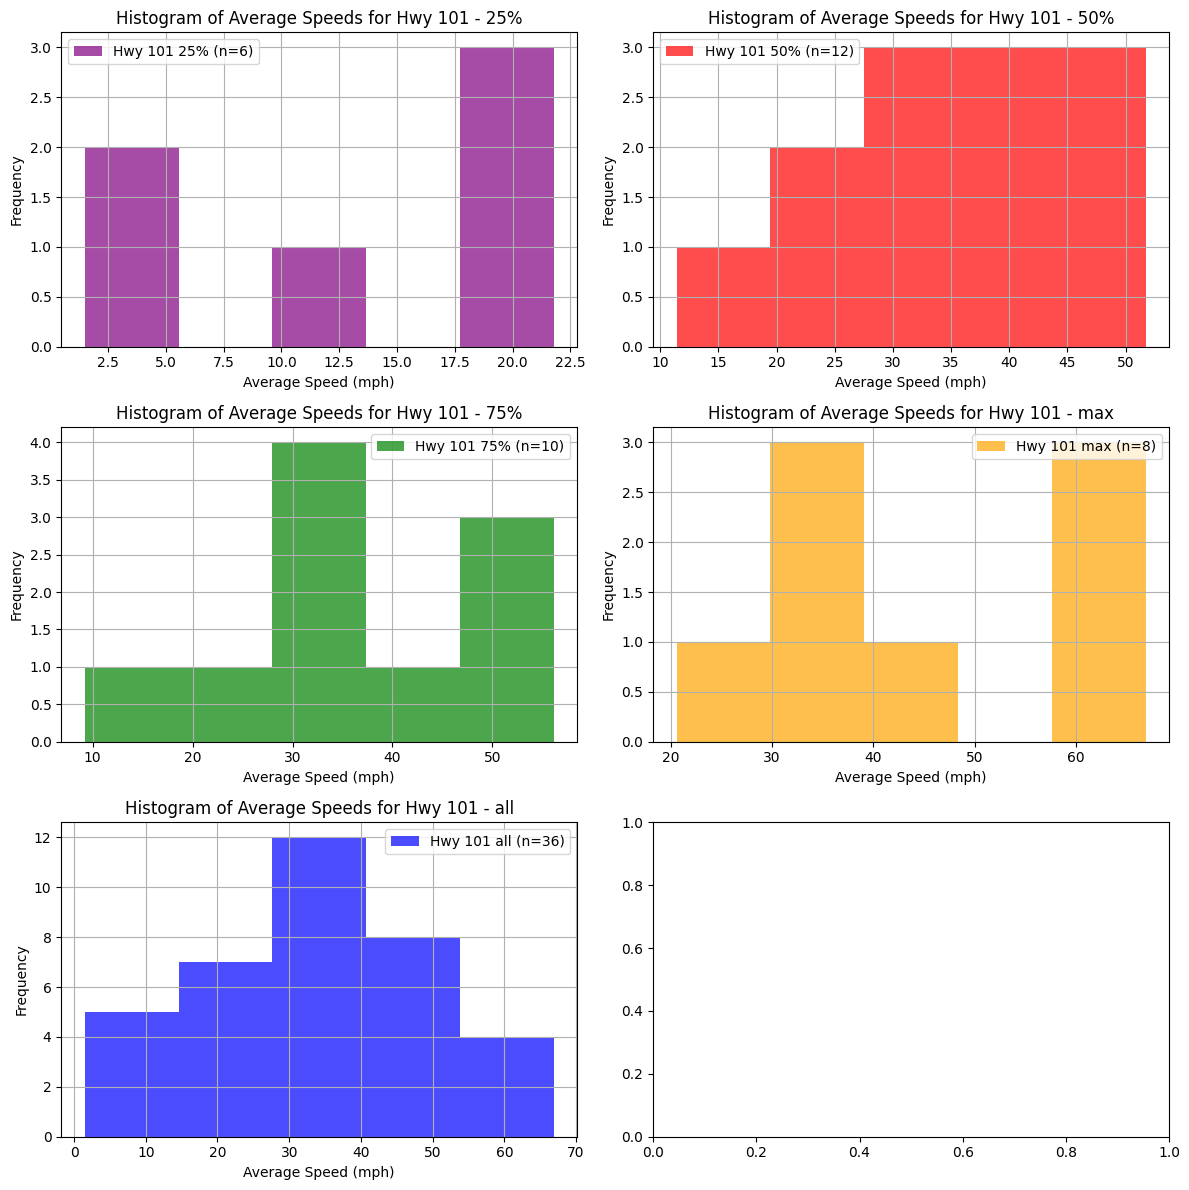

In [181]:
### plot a histogram for each speed_hw101_bins[r][0]['Avg_Speed'] for r in ranges on different subplots in a grid
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
for i, r in enumerate(ranges):  
    ax = axs[i // 2, i % 2]
    if r == 'all':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='blue')
    elif r == 'max':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='orange')
    elif r == '75%':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='green')
    elif r == '50%':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='red')
    elif r == '25%':
        ax.hist(speed_hw101_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 101 {r} (n={len(speed_hw101_bins[r][0])})', color='purple')
    ax.set_title(f'Histogram of Average Speeds for Hwy 101 - {r}')
    ax.set_xlabel('Average Speed (mph)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()


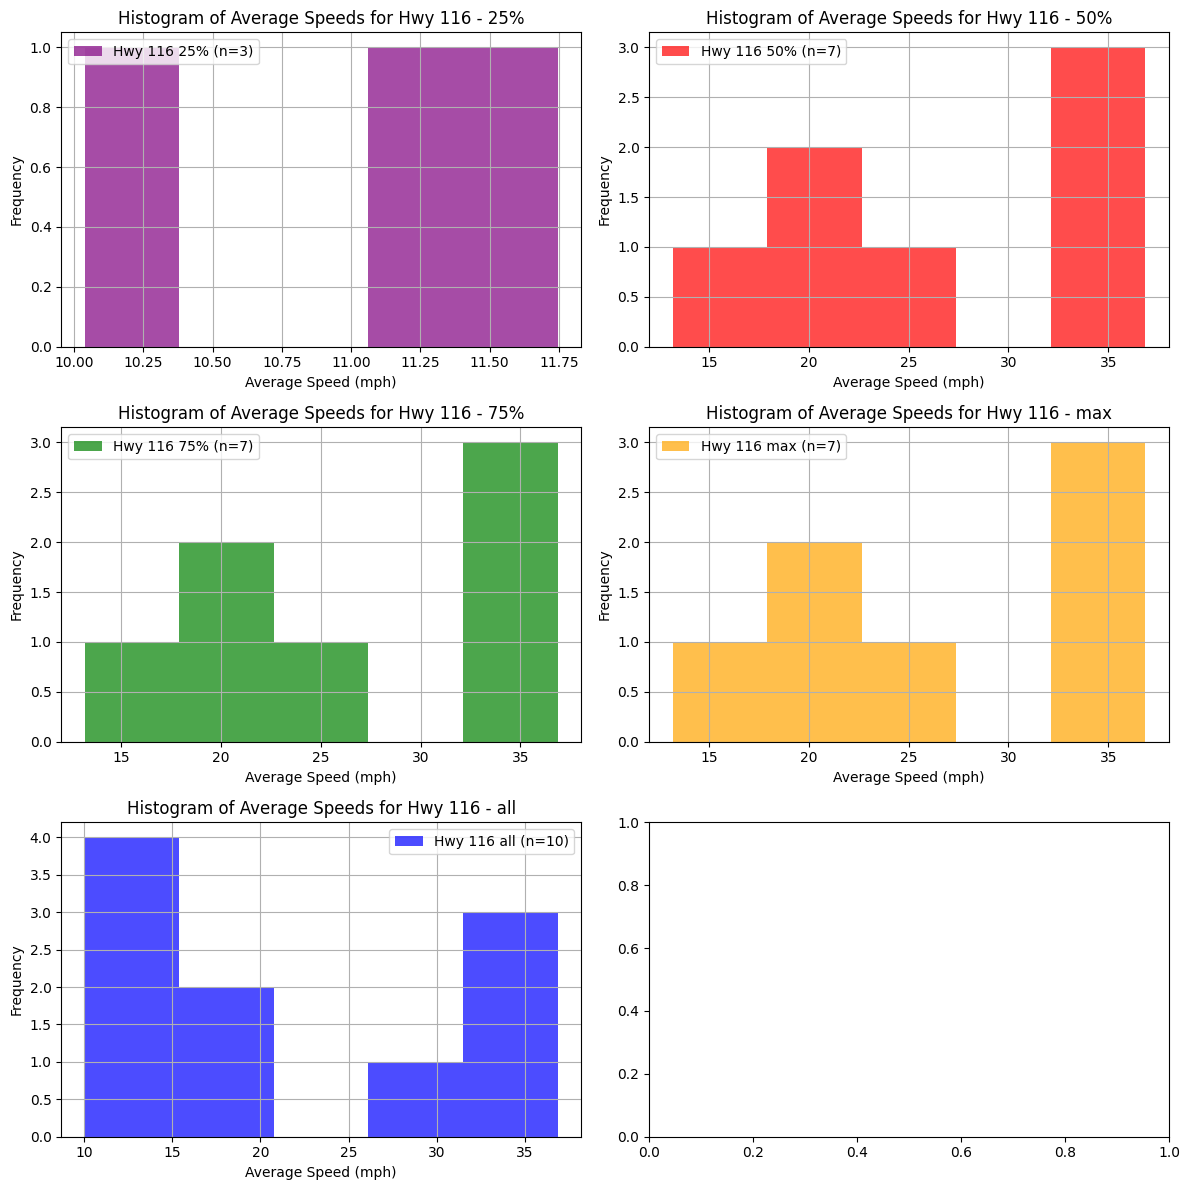

In [182]:
### plot a histogram for each speed_hw101_bins[r][0]['Avg_Speed'] for r in ranges on different subplots in a grid
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
for i, r in enumerate(ranges):  
    ax = axs[i // 2, i % 2]
    if r == 'all':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='blue')
    elif r == 'max':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='orange')
    elif r == '75%':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='green')
    elif r == '50%':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='red')
    elif r == '25%':
        ax.hist(speed_hw116_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 116 {r} (n={len(speed_hw116_bins[r][0])})', color='purple')
    ax.set_title(f'Histogram of Average Speeds for Hwy 116 - {r}')
    ax.set_xlabel('Average Speed (mph)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()

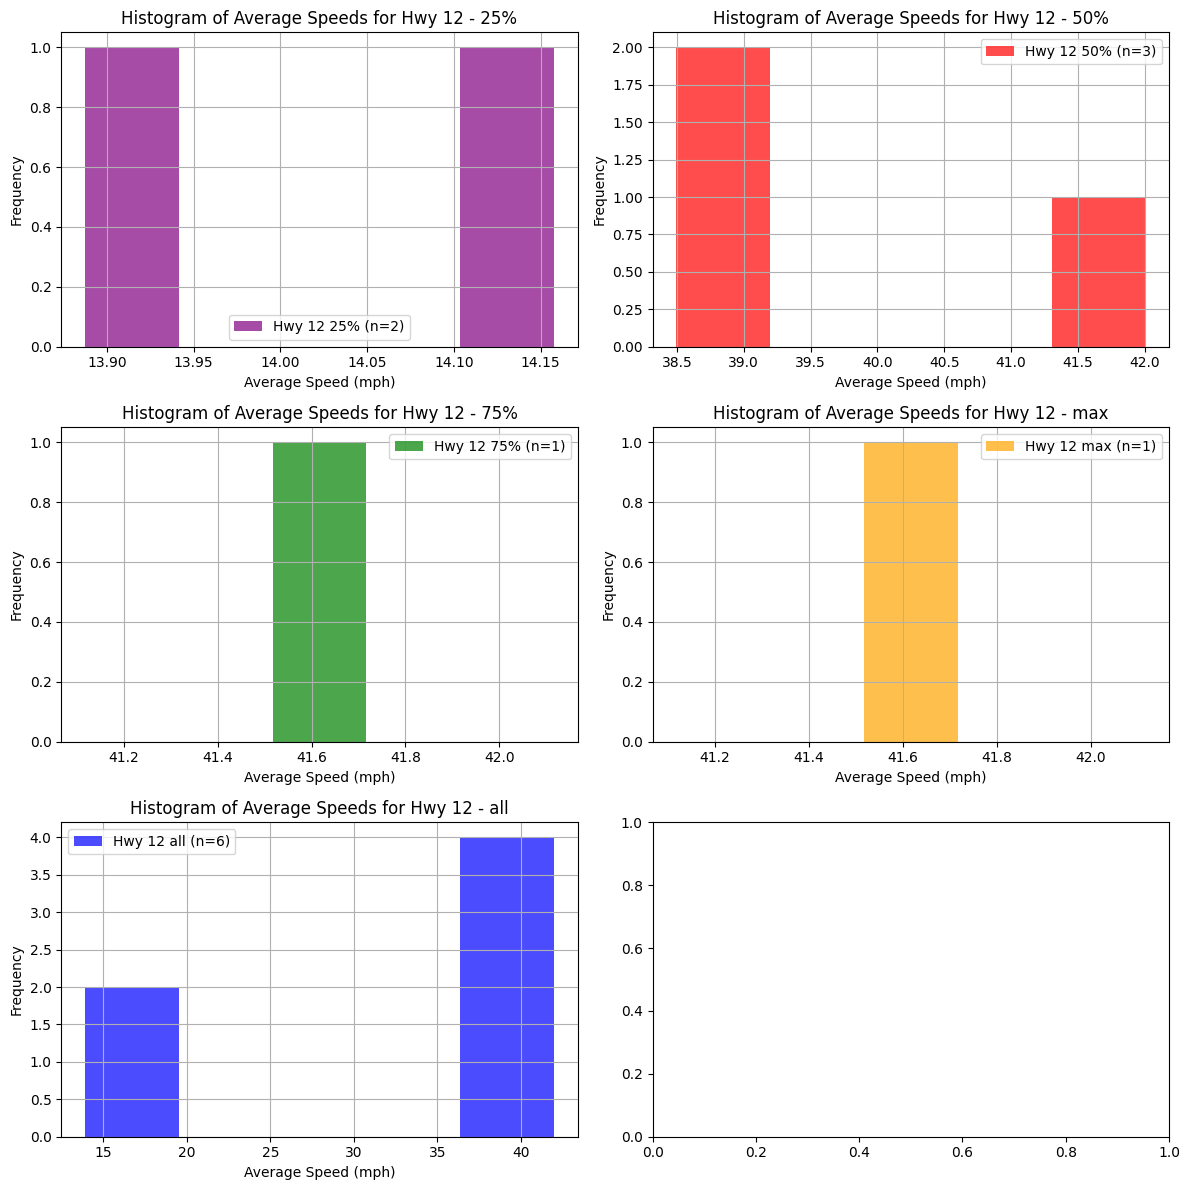

In [183]:
### plot a histogram for each speed_hw101_bins[r][0]['Avg_Speed'] for r in ranges on different subplots in a grid
fig, axs = plt.subplots(3, 2, figsize=(12, 12))
for i, r in enumerate(ranges):  
    ax = axs[i // 2, i % 2]
    if r == 'all':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='blue')
    elif r == 'max':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='orange')
    elif r == '75%':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='green')
    elif r == '50%':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='red')
    elif r == '25%':
        ax.hist(speed_hw12_bins[r][0]['Avg_Speed'], bins=5, alpha=0.7, label=f'Hwy 12 {r} (n={len(speed_hw12_bins[r][0])})', color='purple')
    ax.set_title(f'Histogram of Average Speeds for Hwy 12 - {r}')
    ax.set_xlabel('Average Speed (mph)')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid()
plt.tight_layout()
plt.show()

In [184]:
speed_hw116_bins['75%'][0]

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
823,User308,38.405692,-122.837126,2019-10-26 00:48:00,38.352220,-122.765200,2019-10-26 01:00:00,Hwy 116,Hwy 116,12.0,5.369064,26.845322,2019-10-26,2019-10-26
825,User324,38.425476,-122.848241,2019-10-26 00:31:00,38.472983,-123.016426,2019-10-26 01:15:00,Hwy 116,Hwy 116,44.0,9.674525,13.192534,2019-10-26,2019-10-26
833,User632,38.437149,-122.857682,2019-10-26 00:13:00,38.478219,-122.997329,2019-10-26 00:40:00,Hwy 116,Hwy 116,27.0,8.070864,17.935254,2019-10-26,2019-10-26
838,User889,38.452212,-122.868497,2019-10-26 00:09:00,38.365352,-122.781765,2019-10-26 00:32:00,Hwy 116,Hwy 116,23.0,7.620221,19.878838,2019-10-26,2019-10-26
840,User891,38.330934,-122.710440,2019-10-26 00:38:00,38.379428,-122.799103,2019-10-26 00:48:00,Hwy 116,Hwy 116,10.0,5.856962,35.141774,2019-10-26,2019-10-26
857,User1615,38.331491,-122.714259,2019-10-26 00:13:00,38.389084,-122.815067,2019-10-26 00:24:00,Hwy 116,Hwy 116,11.0,6.757457,36.858857,2019-10-26,2019-10-26
860,User1683,38.442041,-122.860987,2019-10-26 00:05:00,38.499162,-122.972438,2019-10-26 00:17:00,Hwy 116,Hwy 116,12.0,7.205863,36.029314,2019-10-26,2019-10-26


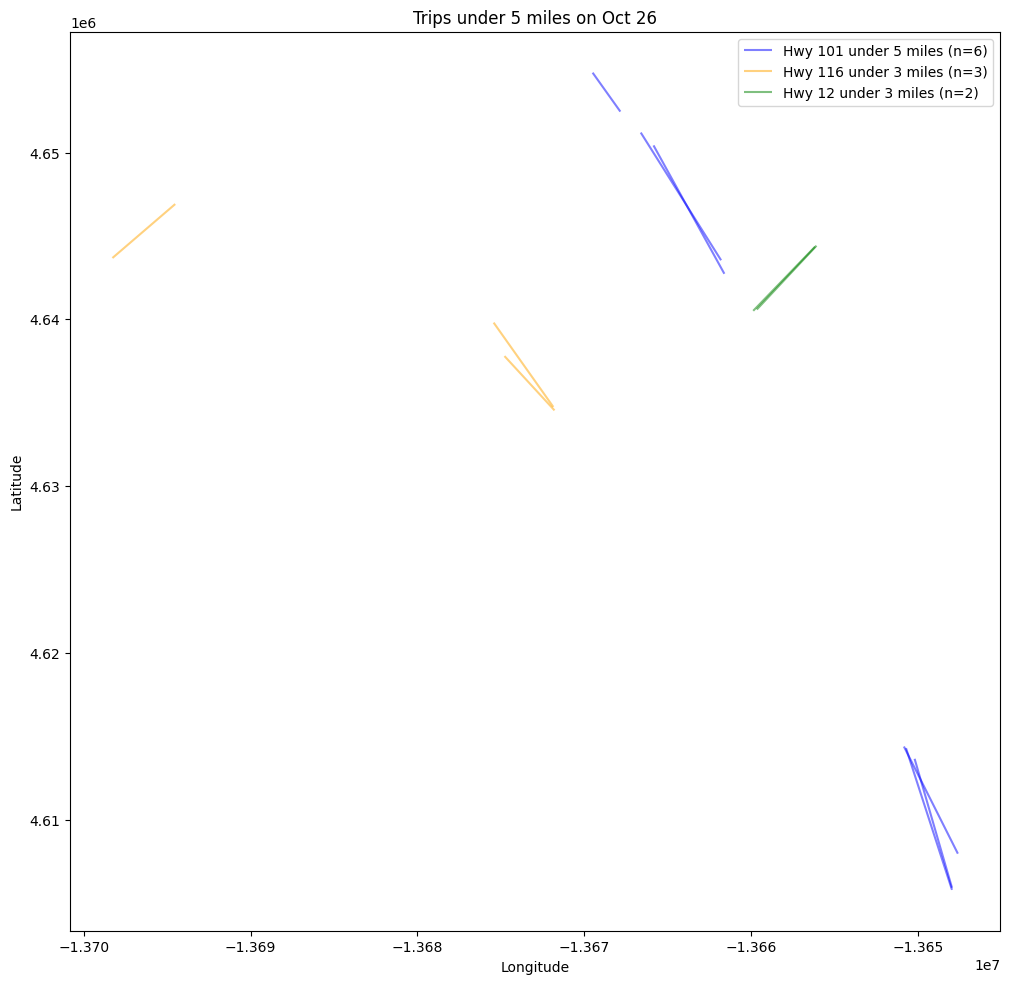

In [185]:
### create a geodataframe linestring for speed_hw101_bins['25%'][0] based on Entrance_Lat, Entrance_Lon, Exit_Lat, Exit_Lon
import geopandas as gpd
from shapely.geometry import LineString
import contextily as ctx
import matplotlib.pyplot as plt

perc = '25%'

gdf_hw101_25 = gpd.GeoDataFrame(speed_hw101_bins[perc][0], geometry=gpd.points_from_xy(speed_hw101_bins[perc][0]['Entrance_LON'], speed_hw101_bins[perc][0]['Entrance_LAT']))
gdf_hw101_25['Exit_Point'] = gpd.points_from_xy(speed_hw101_bins[perc][0]['Exit_LON'], speed_hw101_bins[perc][0]['Exit_LAT'])
gdf_hw101_25['geometry'] = gdf_hw101_25.apply(lambda row: LineString([row['geometry'], row['Exit_Point']]), axis=1)
gdf_hw101_25 = gdf_hw101_25.drop(columns=['Exit_Point'])
gdf_hw101_25.set_crs(epsg=4326, inplace=True)
gdf_hw116_25 = gpd.GeoDataFrame(speed_hw116_bins[perc][0], geometry=gpd.points_from_xy(speed_hw116_bins[perc][0]['Entrance_LON'], speed_hw116_bins[perc][0]['Entrance_LAT']))
gdf_hw116_25['Exit_Point'] = gpd.points_from_xy(speed_hw116_bins[perc][0]['Exit_LON'], speed_hw116_bins[perc][0]['Exit_LAT'])
gdf_hw116_25['geometry'] = gdf_hw116_25.apply(lambda row: LineString([row['geometry'], row['Exit_Point']]), axis=1)
gdf_hw116_25 = gdf_hw116_25.drop(columns=['Exit_Point'])
gdf_hw116_25.set_crs(epsg=4326, inplace=True)
gdf_hw12_25 = gpd.GeoDataFrame(speed_hw12_bins[perc][0], geometry=gpd.points_from_xy(speed_hw12_bins[perc][0]['Entrance_LON'], speed_hw12_bins[perc][0]['Entrance_LAT']))
gdf_hw12_25['Exit_Point'] = gpd.points_from_xy(speed_hw12_bins[perc][0]['Exit_LON'], speed_hw12_bins[perc][0]['Exit_LAT'])        
gdf_hw12_25['geometry'] = gdf_hw12_25.apply(lambda row: LineString([row['geometry'], row['Exit_Point']]), axis=1)
gdf_hw12_25 = gdf_hw12_25.drop(columns=['Exit_Point'])
gdf_hw12_25.set_crs(epsg=4326, inplace=True)
### plot plot all the gdf on the same plot with different colors and a legend
fig, ax = plt.subplots(figsize=(12, 12))
gdf_hw101_25.to_crs(epsg=3857).plot(ax=ax, color='blue', alpha=0.5, label=f'Hwy 101 under 5 miles (n={len(gdf_hw101_25)})')
gdf_hw116_25.to_crs(epsg=3857).plot(ax=ax, color='orange', alpha=0.5, label=f'Hwy 116 under 3 miles (n={len(gdf_hw116_25)})')
gdf_hw12_25.to_crs(epsg=3857).plot(ax=ax, color='green', alpha=0.5, label=f'Hwy 12 under 3 miles (n={len(gdf_hw12_25)})')
ax.legend()
plt.title('Trips under 5 miles on Oct 26')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [186]:
print(len(gdf_hw101_25), len(gdf_hw116_25), len(gdf_hw12_25))

6 3 2


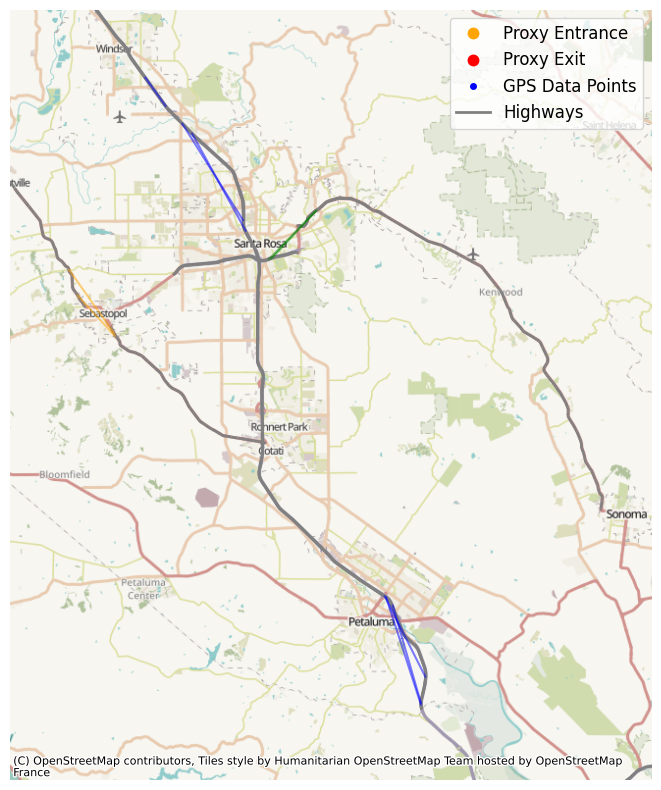

In [187]:
### adjust the code below to overlay gdf_hw101_25 on top of a map of highways in the area
import geopandas as gpd
import contextily as cx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1,figsize=(10, 10),dpi=100)
highways = gpd.read_file('Highways.shp')
highways = highways.to_crs(epsg=3857)
highways.plot(ax=ax, color='gray', linewidth=2, zorder=1)

#gdf_hw101_25.to_crs(epsg=3857).plot(ax=ax,color='b',markersize=10, zorder=2)
gdf_hw101_25.to_crs(epsg=3857).plot(ax=ax, color='blue', alpha=0.5, label=f'Hwy 101 under 5 miles (n={len(gdf_hw101_25)})')
gdf_hw116_25.to_crs(epsg=3857).plot(ax=ax, color='orange', alpha=0.5, label=f'Hwy 116 under 3 miles (n={len(gdf_hw116_25)})')
gdf_hw12_25.to_crs(epsg=3857).plot(ax=ax, color='green', alpha=0.5, label=f'Hwy 12 under 3 miles (n={len(gdf_hw12_25)})')
#gdf_hw101_25.to_crs(epsg=3857).loc[[exit_index]].plot(ax=ax,color='r',markersize=50, zorder=3)  

legend_elements = [Line2D([0], [0], marker='.', color='orange', lw=0, markersize=15, label='Proxy Entrance'),
                   Line2D([0], [0], marker='.', color='r', lw=0, markersize=15, label='Proxy Exit'),
                   Line2D([0], [0], marker='.', color='b', lw=0, markersize=8, label='GPS Data Points'),
                   Line2D([0], [0], marker='.', color='gray', lw=2, markersize=0, markerfacecolor='k', label='Highways'),
                  ]
ax.legend(handles=legend_elements,fontsize=12)

ax.set_ylim(4600000, 4660000)
ax.set_xlim(-13680000, -13630000)
ax.axis('off')

cx.add_basemap(ax)

In [188]:
### create a geodataframe that is the 25% for each highway
hw101_25_gdf = gpd.GeoDataFrame(speed_hw101_bins['25%'][0], geometry=gpd.points_from_xy(speed_hw101_bins['25%'][0]['Entrance_LON'], speed_hw101_bins['25%'][0]['Entrance_LAT']), crs='EPSG:4326')
hw116_25_gdf = gpd.GeoDataFrame(speed_hw116_bins['25%'][0], geometry=gpd.points_from_xy(speed_hw116_bins['25%'][0]['Entrance_LON'], speed_hw116_bins['25%'][0]['Entrance_LAT']), crs='EPSG:4326')
hw12_25_gdf = gpd.GeoDataFrame(speed_hw12_bins['25%'][0], geometry=gpd.points_from_xy(speed_hw12_bins['25%'][0]['Entrance_LON'], speed_hw12_bins['25%'][0]['Entrance_LAT']), crs='EPSG:4326')

hw101_50_gdf = gpd.GeoDataFrame(speed_hw101_bins['50%'][0], geometry=gpd.points_from_xy(speed_hw101_bins['50%'][0]['Entrance_LON'], speed_hw101_bins['50%'][0]['Entrance_LAT']), crs='EPSG:4326')
hw116_50_gdf = gpd.GeoDataFrame(speed_hw116_bins['50%'][0], geometry=gpd.points_from_xy(speed_hw116_bins['50%'][0]['Entrance_LON'], speed_hw116_bins['50%'][0]['Entrance_LAT']), crs='EPSG:4326')
hw12_50_gdf = gpd.GeoDataFrame(speed_hw12_bins['50%'][0], geometry=gpd.points_from_xy(speed_hw12_bins['50%'][0]['Entrance_LON'], speed_hw12_bins['50%'][0]['Entrance_LAT']), crs='EPSG:4326')

In [189]:
len(hw101_50_gdf)

12

In [190]:
### convert hour column of hw101_25_gdf to rounded integer of hour from Entrance_TIMESTAMP
hw101_25_gdf['Hour'] = hw101_25_gdf['Entrance_TIMESTAMP'].dt.hour.round().astype(int)

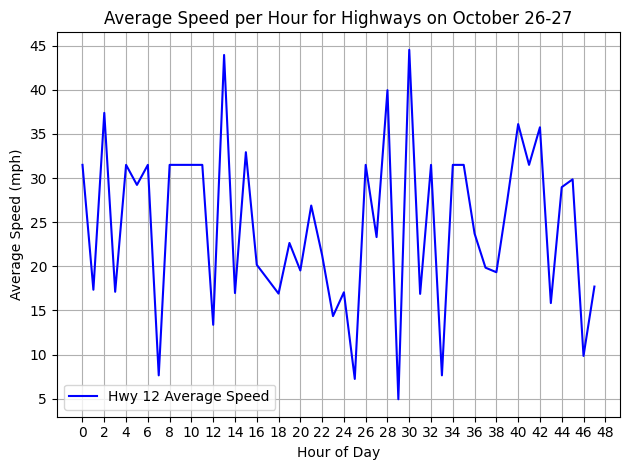

In [191]:
### Plot speed_hw12_avg_list as a line graph
plt.plot(range(48), speed_hw12_avg_list, label='Hwy 12 Average Speed', color='blue')
#plt.plot(range(48), speed_hw116_avg_list, label='Hwy 116 Average Speed', color='orange')
#plt.plot(range(48), speed_hw101_avg_list, label='Hwy 101 Average Speed', color='green')
plt.title('Average Speed per Hour for Highways on October 26-27')
plt.xlabel('Hour of Day')
plt.ylabel('Average Speed (mph)')
plt.xticks(range(0, 49, 2))
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

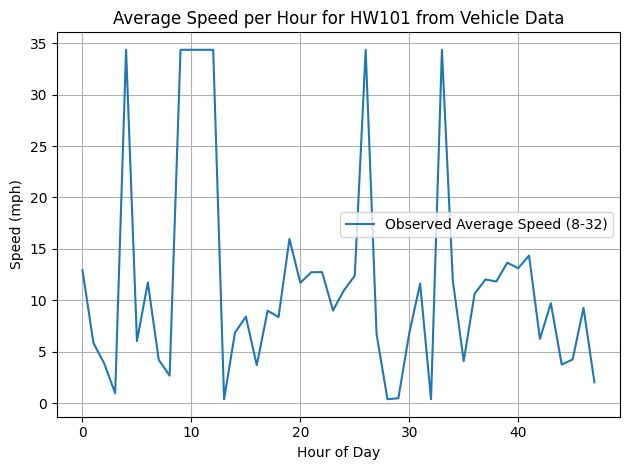

In [192]:
plt.plot(range(48), speed_hw101_avg_list, label='Observed Average Speed (8-32)')
#plt.plot(range(25), hw101_hour_avg, label='Simulated Average Speed')
plt.title('Average Speed per Hour for HW101 from Vehicle Data')
plt.xlabel('Hour of Day')
plt.ylabel('Speed (mph)')
#plt.xticks(range(0, 24, 2)) # Show x-ticks every 2 hours
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [196]:
### measure the error of speed_hw101_avg_list and hw101_ladris_speed_congestion for the first 24 elements
from sklearn.metrics import mean_squared_error
import numpy as np  

lower_segids = []
for segid in hw101_ladris_speed_congestion.keys():
    sim_speeds = [time[1] for time in hw101_ladris_speed_congestion[segid][:24]]
    if len(sim_speeds) == 24:
        mse = mean_squared_error(speed_hw101_avg_list[:24], sim_speeds)
        rmse = np.sqrt(mse)
        #print(f"Segment ID: {segid}, RMSE: {rmse}")
        if rmse < 30:
            lower_segids.append(segid)
print(f"Number of segments with RMSE < 30: {len(lower_segids)}")






Number of segments with RMSE < 30: 37


In [224]:
filtered_hw101_southbound.index

Index([121, 122, 124, 125, 126, 127, 128, 129, 130, 132,
       ...
       805, 806, 808, 810, 811, 812, 815, 816, 817, 818],
      dtype='int64', length=473)

In [362]:
### compute the average rmse for all segments in hw101_ladris_speed_congestion
total_rmse = 0
count = 0
for segid in hw101_ladris_speed_congestion.keys():
    sim_speeds = [time[1] for time in hw101_ladris_speed_congestion[segid][:24]]
    if len(sim_speeds) == 24:
        mse = mean_squared_error(speed_hw101_avg_list[:24], sim_speeds)
        rmse = np.sqrt(mse)
        total_rmse += rmse
        count += 1
average_rmse = total_rmse / count
print(f"Average RMSE for HW101 segments: {average_rmse}, Count: {count}")



Average RMSE for HW101 segments: 24.6445589038765, Count: 50


In [198]:
print(len(speed_hw116_avg_list))

48


In [199]:
### compute the average rmse for all segments in hw116_ladris_speed_congestion
total_rmse = 0
count = 0
for segid in hw116_ladris_speed_congestion.keys():
    sim_speeds = [time[1] for time in hw116_ladris_speed_congestion[segid][:24]]
    if len(sim_speeds) == 24:
        mse = mean_squared_error(speed_hw116_avg_list[:24], sim_speeds)
        rmse = np.sqrt(mse)
        total_rmse += rmse
        count += 1
average_rmse = total_rmse / count
print(f"Average RMSE for HW116 segments: {average_rmse}")



Average RMSE for HW116 segments: 22.70540163134217


In [200]:
### compute the average rmse for all segments in hw12_ladris_speed_congestion
total_rmse = 0
count = 0
for segid in hw12_ladris_speed_congestion.keys():
    sim_speeds = [time[1] for time in hw12_ladris_speed_congestion[segid][:24]]
    if len(sim_speeds) == 24:
        mse = mean_squared_error(speed_hw12_avg_list[:24], sim_speeds)
        rmse = np.sqrt(mse)
        total_rmse += rmse
        count += 1
average_rmse = total_rmse / count
print(f"Average RMSE for HW12 segments: {average_rmse}")

Average RMSE for HW12 segments: 27.040584583280836


# What we have so far
- all_consecutive_segments: key is index of filtered_hw101 value is list of consecutive model segments
- hw101_ladris_speed_congestion: key is segment and value is a list of speeds by simulated time
- filtered_hw101_southbound: dataview of the observed data results (index is key)

In [ ]:
all_consecutive_segments[121]

[28835052,
 28855561,
 28855562,
 28799967,
 28795090,
 28800206,
 28874256,
 28780003,
 28780001,
 28780769]

In [240]:
hw101_ladris_speed_congestion[28857931]

[(1, 2.950000000000003),
 (2, 2.950000000000003),
 (3, 1.180000000000001),
 (4, 1.180000000000001),
 (5, 1.180000000000001),
 (6, 1.180000000000001),
 (7, 1.180000000000001),
 (8, 1.180000000000001),
 (9, 1.180000000000001),
 (10, 1.180000000000001),
 (11, 1.180000000000001),
 (12, 1.180000000000001),
 (13, 1.180000000000001),
 (14, 1.180000000000001),
 (15, 1.180000000000001),
 (16, 1.180000000000001),
 (17, 1.180000000000001),
 (18, 1.180000000000001),
 (19, 1.180000000000001),
 (20, 1.180000000000001),
 (21, 1.180000000000001),
 (22, 1.180000000000001),
 (23, 1.180000000000001),
 (24, 59.0),
 (25, 59.0),
 (26, 59.0),
 (27, 59.0),
 (28, 59.0),
 (29, 59.0),
 (30, 59.0),
 (31, 59.0),
 (32, 59.0),
 (33, 59.0),
 (34, 59.0),
 (35, 59.0),
 (36, 59.0),
 (37, 59.0),
 (38, 59.0),
 (39, 59.0)]

In [205]:
### for index 121, print the index, Entrance_TIMESTAMP, and average speed from filtered_hw101_southbound[index]
index = 121
entry_time = filtered_hw101_southbound.iloc[index]['Entrance_TIMESTAMP']
avg_speed = filtered_hw101_southbound.iloc[index]['Avg_Speed']
print(f"Index: {index}, Entrance_TIMESTAMP: {entry_time}, Average Speed: {avg_speed}")

Index: 121, Entrance_TIMESTAMP: 2019-10-26 23:57:00, Average Speed: 25.84554519470504


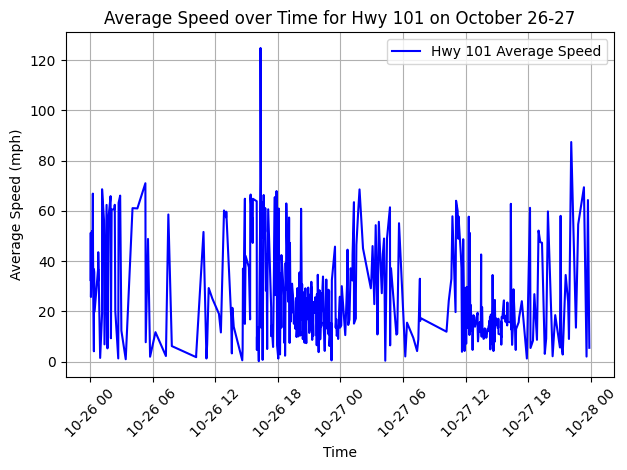

In [207]:
### print filtered_hw101_southbound sorted by Entrance_TIMESTAMP
sortedTimes = filtered_hw101_southbound.sort_values(by='Entrance_TIMESTAMP')["Entrance_TIMESTAMP"].tolist()
sortedSpeeds = filtered_hw101_southbound.sort_values(by='Entrance_TIMESTAMP')["Avg_Speed"].tolist()

### Plot sortedSpeeds as a line graph with the x axis as sortedTimes
plt.plot(sortedTimes, sortedSpeeds, label='Hwy 101 Average Speed', color='blue')
plt.title('Average Speed over Time for Hwy 101 on October 26-27')
plt.xlabel('Time')
plt.ylabel('Average Speed (mph)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [230]:
filtered_hw101_southbound

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
121,User4,38.482038,-122.736489,2019-10-26 17:22:00,38.430883,-122.714817,2019-10-26 17:44:00,Hwy 101,Hwy 101,22.0,3.723896,10.156080,2019-10-26,2019-10-26 17:00:00
122,User4,38.558857,-122.820303,2019-10-27 12:23:00,38.459379,-122.726361,2019-10-27 12:33:00,Hwy 101,Hwy 101,10.0,8.546274,51.277643,2019-10-27,2019-10-27 12:00:00
124,User9,38.374793,-122.716104,2019-10-27 02:55:00,38.200342,-122.598903,2019-10-27 03:23:00,Hwy 101,Hwy 101,28.0,13.626580,29.199814,2019-10-27,2019-10-27 02:00:00
125,User12,38.525769,-122.790176,2019-10-26 19:01:00,38.365738,-122.712714,2019-10-26 19:23:00,Hwy 101,Hwy 101,22.0,11.824955,32.249878,2019-10-26,2019-10-26 19:00:00
126,User13,38.342392,-122.713057,2019-10-26 20:58:00,38.195579,-122.599847,2019-10-26 21:41:00,Hwy 101,Hwy 101,43.0,11.857937,16.545959,2019-10-26,2019-10-26 20:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,User2484,38.380372,-122.716405,2019-10-27 02:54:00,38.204119,-122.598688,2019-10-27 03:22:00,Hwy 101,Hwy 101,28.0,13.749614,29.463459,2019-10-27,2019-10-27 02:00:00
815,User2503,38.426506,-122.715160,2019-10-26 06:17:00,38.392560,-122.716190,2019-10-26 06:29:00,Hwy 101,Hwy 101,12.0,2.346104,11.730520,2019-10-26,2019-10-26 06:00:00
816,User2505,38.376080,-122.716748,2019-10-27 11:18:00,38.241927,-122.621948,2019-10-27 11:31:00,Hwy 101,Hwy 101,13.0,10.598681,48.916987,2019-10-27,2019-10-27 11:00:00
817,User2508,38.446547,-122.724602,2019-10-27 21:49:00,38.348400,-122.713401,2019-10-27 22:06:00,Hwy 101,Hwy 101,17.0,6.808371,24.029545,2019-10-27,2019-10-27 21:00:00


In [219]:
### for each segment in all_consecutive_segments produce a dictionary of segment id to count of that segment in all keys of all_consecutive_segments
segment_count = {}
segment_overlap_ids = {}
for key in all_consecutive_segments.keys():
    segments = all_consecutive_segments[key]
    print(key)
    if segments != None:        
        for seg in segments:
            if seg in segment_count:
                segment_count[seg] += 1
                segment_overlap_ids[seg].add(key)
            else:
                segment_count[seg] = 1
                segment_overlap_ids[seg] = {key}
segment_count

121
122
124
125
126
127
128
129
130
132
133
135
136
138
139
140
141
143
144
147
148
149
150
151
153
155
157
158
159
162
165
167
169
170
172
174
175
176
179
180
181
182
184
185
186
187
189
190
192
193
195
196
197
198
200
201
202
203
206
207
208
209
210
211
212
214
215
216
218
219
220
221
222
223
224
225
226
227
229
230
232
233
234
235
236
238
240
241
242
244
245
246
247
248
250
251
252
254
256
260
261
262
263
265
266
267
268
270
271
272
275
277
280
281
283
284
285
287
288
291
293
294
296
301
303
304
306
307
309
310
312
313
314
316
317
318
319
320
321
323
325
329
330
331
332
333
334
335
336
338
339
341
342
345
347
349
355
356
358
359
360
361
363
364
366
367
369
371
372
373
374
375
379
380
381
382
383
385
386
387
388
389
393
394
395
396
397
398
399
400
401
403
406
408
409
410
411
412
413
414
415
416
417
420
422
426
427
428
429
430
431
433
434
435
436
437
439
442
443
444
445
447
449
450
452
454
455
458
459
463
464
465
466
467
468
469
470
472
473
475
476
477
478
479
480
482
483
484
485
486


{28835052: 119,
 28855561: 123,
 28855562: 127,
 28799967: 130,
 28795090: 128,
 28800206: 139,
 28874256: 145,
 28780003: 148,
 28780001: 149,
 28780769: 147,
 28782942: 73,
 28783981: 80,
 28784994: 91,
 28798892: 95,
 28799378: 106,
 28799329: 109,
 28801101: 105,
 28801154: 108,
 28846299: 113,
 28846331: 112,
 28857928: 109,
 28857930: 111,
 28857931: 117,
 28895425: 184,
 28895853: 188,
 28904760: 189,
 28884911: 188,
 28884919: 191,
 28896726: 197,
 28892614: 266,
 28769856: 155,
 28770235: 168,
 28770044: 173,
 28781391: 178,
 28916791: 180,
 28884343: 191,
 28884259: 185,
 28884102: 187,
 28838193: 39,
 28827199: 44,
 28784932: 57,
 28782940: 59,
 28919550: 43,
 28836283: 34}

# TODO
- compute the average time for each consecutive segmet based on the time between entrance and exit from hw101_ladris_speed_congestion

In [ ]:
### Print the time segment for each value of segment_overlap_ids[28835052] mapped to index of filtered_hw101_southbound not the iloc index
times_for_overlap = []
for index in segment_overlap_ids[28835052]:
    entry_time = filtered_hw101_southbound.loc[index]['Entrance_TIMESTAMP']
    exit_time = filtered_hw101_southbound.loc[index]['Exit_TIMESTAMP']
    times_for_overlap.append((index, entry_time, exit_time))

### sort times_for_overlap by entry_time
times_for_overlap = sorted(times_for_overlap, key=lambda x: x[1])
times_for_overlap

[(426, Timestamp('2019-10-26 00:15:00'), Timestamp('2019-10-26 00:30:00')),
 (705, Timestamp('2019-10-26 00:23:00'), Timestamp('2019-10-26 01:25:00')),
 (212, Timestamp('2019-10-26 00:23:00'), Timestamp('2019-10-26 00:38:00')),
 (182, Timestamp('2019-10-26 00:25:00'), Timestamp('2019-10-26 00:55:00')),
 (280, Timestamp('2019-10-26 00:47:00'), Timestamp('2019-10-26 01:46:00')),
 (247, Timestamp('2019-10-26 00:48:00'), Timestamp('2019-10-26 01:29:00')),
 (785, Timestamp('2019-10-26 01:10:00'), Timestamp('2019-10-26 01:37:00')),
 (430, Timestamp('2019-10-26 01:21:00'), Timestamp('2019-10-26 01:33:00')),
 (236, Timestamp('2019-10-26 01:36:00'), Timestamp('2019-10-26 02:07:00')),
 (139, Timestamp('2019-10-26 01:48:00'), Timestamp('2019-10-26 02:03:00')),
 (345, Timestamp('2019-10-26 01:59:00'), Timestamp('2019-10-26 02:10:00')),
 (725, Timestamp('2019-10-26 02:01:00'), Timestamp('2019-10-26 02:34:00')),
 (769, Timestamp('2019-10-26 02:23:00'), Timestamp('2019-10-26 02:38:00')),
 (628, Times

In [244]:
### for each key in consecutive_segments, get the start and end time from times_for_overlap and determine the start hour and end hour with respect from 0 being 2019-10-26 00:00
segment_time_ranges = {}
for key in all_consecutive_segments.keys():
    segments = all_consecutive_segments[key]
    if segments != None:
        entry_time = filtered_hw101_southbound.loc[key]['Entrance_TIMESTAMP']
        exit_time = filtered_hw101_southbound.loc[key]['Exit_TIMESTAMP']
        start_hour = int((entry_time - pd.Timestamp('2019-10-26')).total_seconds() // 3600)
        end_hour = int((exit_time - pd.Timestamp('2019-10-26')).total_seconds() // 3600)
        segment_time_ranges[key] = (start_hour, end_hour)
segment_time_ranges

segment_time_ranges[121]

(17, 17)

In [246]:
hw101_ladris_speed_congestion

{28857931: [(1, 2.950000000000003),
  (2, 2.950000000000003),
  (3, 1.180000000000001),
  (4, 1.180000000000001),
  (5, 1.180000000000001),
  (6, 1.180000000000001),
  (7, 1.180000000000001),
  (8, 1.180000000000001),
  (9, 1.180000000000001),
  (10, 1.180000000000001),
  (11, 1.180000000000001),
  (12, 1.180000000000001),
  (13, 1.180000000000001),
  (14, 1.180000000000001),
  (15, 1.180000000000001),
  (16, 1.180000000000001),
  (17, 1.180000000000001),
  (18, 1.180000000000001),
  (19, 1.180000000000001),
  (20, 1.180000000000001),
  (21, 1.180000000000001),
  (22, 1.180000000000001),
  (23, 1.180000000000001),
  (24, 59.0),
  (25, 59.0),
  (26, 59.0),
  (27, 59.0),
  (28, 59.0),
  (29, 59.0),
  (30, 59.0),
  (31, 59.0),
  (32, 59.0),
  (33, 59.0),
  (34, 59.0),
  (35, 59.0),
  (36, 59.0),
  (37, 59.0),
  (38, 59.0),
  (39, 59.0)],
 28857930: [(1, 1.180000000000001),
  (2, 1.180000000000001),
  (3, 1.180000000000001),
  (4, 1.180000000000001),
  (5, 1.180000000000001),
  (6, 1.18000

# Generate data structure that has average spped for modeled consecutive segments with respect to observed index

In [261]:
print(all_consecutive_segments[121])
print(segment_time_ranges[121])
tmp_speeds = []
for k in all_consecutive_segments[121]:
    tmp_speeds.append(hw101_ladris_speed_congestion[k][16][1])
    print(hw101_ladris_speed_congestion[k][16][1])
print("average tmp speed for 121:", sum(tmp_speeds)/len(tmp_speeds))



[28835052, 28855561, 28855562, 28799967, 28795090, 28800206, 28874256, 28780003, 28780001, 28780769]
(17, 17)
1.180000000000001
1.180000000000001
1.180000000000001
1.180000000000001
1.180000000000001
1.180000000000001
1.180000000000001
1.180000000000001
1.180000000000001
59.0
average tmp speed for 121: 6.962000000000001


In [275]:
### compute the average speed of the consecutive_segments[key] for each hour from segment_time_ranges[key] and compare to hw101_ladris_speed_congestion for each segment in consecutive_segments[key] for that hour range
simulated_consecutive_segment_avg_speeds = {}
tmp_speeds = []
for key in all_consecutive_segments.keys():
    segments = all_consecutive_segments[key]
    if segments != None:
        start_hour, end_hour = segment_time_ranges[key]        
        hour = start_hour-1
        hour_speeds = []
        for seg in segments:
            if hour < hw101_ladris_speed_congestion[seg][-1][0]:
                hour_speeds.append(hw101_ladris_speed_congestion[seg][hour][1])
        if hour_speeds:
            avg_speed = sum(hour_speeds) / len(hour_speeds)
            simulated_consecutive_segment_avg_speeds[key] = avg_speed
            
simulated_consecutive_segment_avg_speeds

{121: 6.962000000000001,
 122: 59.0,
 124: 9.440000000000001,
 125: 3.321481481481484,
 126: 1.180000000000001,
 127: 59.0,
 128: 1.1800000000000013,
 129: 25.271666666666672,
 130: 31.79058823529412,
 132: 59.0,
 133: 2.8910000000000005,
 135: 1.180000000000001,
 136: 2.360000000000002,
 138: 28.424117647058825,
 139: 5.436428571428574,
 140: 59.0,
 141: 14.320909090909096,
 143: 2.1830000000000003,
 144: 4.793750000000001,
 147: 50.74,
 148: 6.962000000000003,
 149: 1.180000000000001,
 150: 1.180000000000001,
 151: 59.0,
 153: 1.180000000000001,
 155: 44.545000000000016,
 157: 54.87,
 159: 59.0,
 162: 1.180000000000001,
 165: 55.78777777777778,
 167: 1.1800000000000013,
 169: 4.237272727272728,
 170: 1.180000000000001,
 172: 1.180000000000001,
 174: 18.18588235294118,
 175: 1.180000000000001,
 176: 59.0,
 179: 49.36333333333334,
 182: 59.0,
 184: 4.7761904761904805,
 185: 1.180000000000001,
 186: 1.180000000000001,
 189: 2.9499999999999997,
 190: 1.180000000000001,
 192: 8.6287500000

In [276]:
filtered_hw101_southbound

,ID,Entrance_LAT,Entrance_LON,Entrance_TIMESTAMP,Exit_LAT,Exit_LON,Exit_TIMESTAMP,Entrance_HWY,Exit_HWY,Travel_Time,Distance,Avg_Speed,Date,Hour
121,User4,38.482038,-122.736489,2019-10-26 17:22:00,38.430883,-122.714817,2019-10-26 17:44:00,Hwy 101,Hwy 101,22.0,3.723896,10.156080,2019-10-26,2019-10-26 17:00:00
122,User4,38.558857,-122.820303,2019-10-27 12:23:00,38.459379,-122.726361,2019-10-27 12:33:00,Hwy 101,Hwy 101,10.0,8.546274,51.277643,2019-10-27,2019-10-27 12:00:00
124,User9,38.374793,-122.716104,2019-10-27 02:55:00,38.200342,-122.598903,2019-10-27 03:23:00,Hwy 101,Hwy 101,28.0,13.626580,29.199814,2019-10-27,2019-10-27 02:00:00
125,User12,38.525769,-122.790176,2019-10-26 19:01:00,38.365738,-122.712714,2019-10-26 19:23:00,Hwy 101,Hwy 101,22.0,11.824955,32.249878,2019-10-26,2019-10-26 19:00:00
126,User13,38.342392,-122.713057,2019-10-26 20:58:00,38.195579,-122.599847,2019-10-26 21:41:00,Hwy 101,Hwy 101,43.0,11.857937,16.545959,2019-10-26,2019-10-26 20:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
812,User2484,38.380372,-122.716405,2019-10-27 02:54:00,38.204119,-122.598688,2019-10-27 03:22:00,Hwy 101,Hwy 101,28.0,13.749614,29.463459,2019-10-27,2019-10-27 02:00:00
815,User2503,38.426506,-122.715160,2019-10-26 06:17:00,38.392560,-122.716190,2019-10-26 06:29:00,Hwy 101,Hwy 101,12.0,2.346104,11.730520,2019-10-26,2019-10-26 06:00:00
816,User2505,38.376080,-122.716748,2019-10-27 11:18:00,38.241927,-122.621948,2019-10-27 11:31:00,Hwy 101,Hwy 101,13.0,10.598681,48.916987,2019-10-27,2019-10-27 11:00:00
817,User2508,38.446547,-122.724602,2019-10-27 21:49:00,38.348400,-122.713401,2019-10-27 22:06:00,Hwy 101,Hwy 101,17.0,6.808371,24.029545,2019-10-27,2019-10-27 21:00:00


# Data for Validation
- simulated_consecutive_segment_avg_speeds - average speeds for consecutive segments mapped to observed data index as key
- filtered_hw101_southbound - dataview where index can be key, and column Avg_Speed provides the average speed for that data

### TODO: compare and measure the validation results of the two datasets


In [277]:
print(simulated_consecutive_segment_avg_speeds[121], filtered_hw101_southbound.loc[121]['Avg_Speed'])

6.962000000000001 10.156080030671554


In [339]:
hw101_ladris_speed_congestion[seg]

[(1, 1.180000000000001),
 (2, 1.180000000000001),
 (3, 1.180000000000001),
 (4, 1.180000000000001),
 (5, 1.180000000000001),
 (6, 1.180000000000001),
 (7, 1.180000000000001),
 (8, 1.180000000000001),
 (9, 1.180000000000001),
 (10, 1.180000000000001),
 (11, 1.180000000000001),
 (12, 1.180000000000001),
 (13, 1.180000000000001),
 (14, 1.180000000000001),
 (15, 1.180000000000001),
 (16, 1.180000000000001),
 (17, 1.180000000000001),
 (18, 1.180000000000001),
 (19, 1.180000000000001),
 (20, 1.180000000000001),
 (21, 1.180000000000001),
 (22, 1.180000000000001),
 (23, 1.180000000000001),
 (24, 59.0),
 (25, 59.0),
 (26, 59.0),
 (27, 59.0),
 (28, 59.0),
 (29, 59.0),
 (30, 59.0),
 (31, 59.0),
 (32, 59.0),
 (33, 59.0),
 (34, 59.0),
 (35, 59.0),
 (36, 59.0),
 (37, 59.0),
 (38, 59.0),
 (39, 59.0)]

# Calibration being done with HW101 data
- change the start time iterating through the modeled dataset
- select a time that has a good or low RMSE
- confirm that RMSE for different bins of distance observed trip times

In [344]:
### measure the roote mean squared error between simulated_consecutive_segment_avg_speeds and filtered_hw101_southbound['Avg_Speed'] for the keys in simulated_consecutive_segment_avg_speeds
from sklearn.metrics import mean_squared_error
import numpy as np

for i in range(1, 39):
    ### compute the average speed of the consecutive_segments[key] for each hour from segment_time_ranges[key] and compare to hw101_ladris_speed_congestion for each segment in consecutive_segments[key] for that hour range
    simulated_consecutive_segment_avg_speeds = {}
    tmp_speeds = []
    for key in all_consecutive_segments.keys():
        segments = all_consecutive_segments[key]
        if segments != None:
            start_hour, end_hour = segment_time_ranges[key]        
            hour = i #= start_hour-1
            hour_speeds = []
            for seg in segments:
                if hour < hw101_ladris_speed_congestion[seg][-1][0]:
                    hour_speeds.append(hw101_ladris_speed_congestion[seg][hour][1])
            if hour_speeds:
                avg_speed = sum(hour_speeds) / len(hour_speeds)
                simulated_consecutive_segment_avg_speeds[key] = avg_speed
                
    simulated_consecutive_segment_avg_speeds

    simulated_speeds = []
    observed_speeds = []
    for key in simulated_consecutive_segment_avg_speeds.keys():
        simulated_speeds.append(simulated_consecutive_segment_avg_speeds[key])
        observed_speeds.append(filtered_hw101_southbound.loc[key]['Avg_Speed'])
    mse = mean_squared_error(observed_speeds, simulated_speeds)
    rmse = np.sqrt(mse)
    print(f"time {i} RMSE between simulated and observed speeds: {rmse}, n={len(simulated_speeds)}")


time 1 RMSE between simulated and observed speeds: 23.61960987810787, n=472
time 2 RMSE between simulated and observed speeds: 26.350142026182215, n=472
time 3 RMSE between simulated and observed speeds: 26.334109091532923, n=472
time 4 RMSE between simulated and observed speeds: 26.334109091532923, n=472
time 5 RMSE between simulated and observed speeds: 27.376098627721277, n=472
time 6 RMSE between simulated and observed speeds: 27.974382559945127, n=472
time 7 RMSE between simulated and observed speeds: 27.974382559945127, n=472
time 8 RMSE between simulated and observed speeds: 27.529986612250955, n=472
time 9 RMSE between simulated and observed speeds: 27.48349844835591, n=472
time 10 RMSE between simulated and observed speeds: 27.48349844835591, n=472
time 11 RMSE between simulated and observed speeds: 28.094143704751716, n=472
time 12 RMSE between simulated and observed speeds: 28.1659867487086, n=472
time 13 RMSE between simulated and observed speeds: 28.1659867487086, n=472
ti

In [357]:
### compute the average speed of the consecutive_segments[key] for each hour from segment_time_ranges[key] and compare to hw101_ladris_speed_congestion for each segment in consecutive_segments[key] for that hour range
simulated_consecutive_segment_avg_speeds = {}
tmp_speeds = []
for key in all_consecutive_segments.keys():
    segments = all_consecutive_segments[key]
    if segments != None:
        start_hour, end_hour = segment_time_ranges[key]        
        hour = 22 #= start_hour-1
        hour_speeds = []
        for seg in segments:
            if hour < hw101_ladris_speed_congestion[seg][-1][0]:
                hour_speeds.append(hw101_ladris_speed_congestion[seg][hour][1])
        if hour_speeds:
            avg_speed = sum(hour_speeds) / len(hour_speeds)
            simulated_consecutive_segment_avg_speeds[key] = avg_speed
            
simulated_consecutive_segment_avg_speeds

simulated_speeds = []
observed_speeds = []
for key in simulated_consecutive_segment_avg_speeds.keys():
    simulated_speeds.append(simulated_consecutive_segment_avg_speeds[key])
    observed_speeds.append(filtered_hw101_southbound.loc[key]['Avg_Speed'])
mse = mean_squared_error(observed_speeds, simulated_speeds)
rmse = np.sqrt(mse)
print(f"RMSE between simulated and observed speeds: {rmse}, n={len(simulated_speeds)}")

RMSE between simulated and observed speeds: 27.841340151650815, n=472


In [358]:
### create a list of bins based on speed_hw101_southbound by distance ranges from filtered_hw101_southbound
speed_hw101_bins = {}

### get the distance percentiles for filtered_hw101_southbound
hw101_dists = {}
hw101_dists['25%'] = filtered_hw101_southbound['Distance'].quantile(0.25)
hw101_dists['50%'] = filtered_hw101_southbound['Distance'].quantile(0.50)
hw101_dists['75%'] = filtered_hw101_southbound['Distance'].quantile(0.75)
hw101_dists['max'] = filtered_hw101_southbound['Distance'].max()

ranges = ['25%', '50%', '75%', 'max', 'all']

### print each hw101_dists value
for r in hw101_dists.keys():
    print(f"{r}: {hw101_dists[r]}")
    
### print count of filtered_hw101_southbound in each distance range
for r in ranges:
    if r == '25%':
        count = len(filtered_hw101_southbound[filtered_hw101_southbound['Distance'] < np.floor(hw101_dists['25%'])])
    elif r == '50%':
        count = len(filtered_hw101_southbound[(filtered_hw101_southbound['Distance'] < np.floor(hw101_dists['50%'])) & (filtered_hw101_southbound['Distance'] >= np.floor(hw101_dists['25%']))])
    elif r == '75%':
        count = len(filtered_hw101_southbound[(filtered_hw101_southbound['Distance'] < np.floor(hw101_dists['75%'])) & (filtered_hw101_southbound['Distance'] >= np.floor(hw101_dists['50%']))])
    elif r == 'max':
        count = len(filtered_hw101_southbound[(filtered_hw101_southbound['Distance'] < np.floor(hw101_dists['max'])) & (filtered_hw101_southbound['Distance'] >= np.floor(hw101_dists['75%']))])
    elif r == 'all':
        count = len(filtered_hw101_southbound)
    print(f"Count of filtered_hw101_southbound in {r} range: {count}")

    
    

25%: 4.738261942545399
50%: 8.563218006688656
75%: 13.708715468942627
max: 42.99072596192968
Count of filtered_hw101_southbound in 25% range: 99
Count of filtered_hw101_southbound in 50% range: 120
Count of filtered_hw101_southbound in 75% range: 124
Count of filtered_hw101_southbound in max range: 129
Count of filtered_hw101_southbound in all range: 473


In [359]:
### compare simulated speeds to filtered_hw101_southbound[(np.floor(filtered_hw101_southbound['Distance']) < np.floor(hw101_dists['25%']))][Avg_Speed] for each distance range and store in speed_hw101_bins[r]
simulated_speeds = []
observed_speeds = []
for key in simulated_consecutive_segment_avg_speeds.keys():
    if key in filtered_hw101_southbound[(np.floor(filtered_hw101_southbound['Distance']) < np.floor(hw101_dists['25%']))].index:
        simulated_speeds.append(simulated_consecutive_segment_avg_speeds[key])
        observed_speeds.append(filtered_hw101_southbound.loc[key]['Avg_Speed'])
mse = mean_squared_error(observed_speeds, simulated_speeds)
rmse = np.sqrt(mse)
print(f"RMSE between simulated and observed speeds for lower 25% distances: {rmse} for n={len(observed_speeds)}")

simulated_speeds = []
observed_speeds = []
for key in simulated_consecutive_segment_avg_speeds.keys():
    if key in filtered_hw101_southbound[(np.floor(filtered_hw101_southbound['Distance']) > np.floor(hw101_dists['25%'])) & (np.floor(filtered_hw101_southbound['Distance']) <= np.floor(hw101_dists['50%']))].index:
        simulated_speeds.append(simulated_consecutive_segment_avg_speeds[key])
        observed_speeds.append(filtered_hw101_southbound.loc[key]['Avg_Speed'])
mse = mean_squared_error(observed_speeds, simulated_speeds)
rmse = np.sqrt(mse)
print(f"RMSE between simulated and observed speeds for distances between 25% and 50%: {rmse} for n={len(observed_speeds)}")

simulated_speeds = []
observed_speeds = []
for key in simulated_consecutive_segment_avg_speeds.keys():
    if key in filtered_hw101_southbound[(np.floor(filtered_hw101_southbound['Distance']) > np.floor(hw101_dists['50%'])) & (np.floor(filtered_hw101_southbound['Distance']) <= np.floor(hw101_dists['75%']))].index:
        simulated_speeds.append(simulated_consecutive_segment_avg_speeds[key])
        observed_speeds.append(filtered_hw101_southbound.loc[key]['Avg_Speed'])
mse = mean_squared_error(observed_speeds, simulated_speeds)
rmse = np.sqrt(mse)
print(f"RMSE between simulated and observed speeds for distances between 50% and 75%: {rmse} for n={len(observed_speeds)}")

simulated_speeds = []
observed_speeds = []
for key in simulated_consecutive_segment_avg_speeds.keys():
    if key in filtered_hw101_southbound[(np.floor(filtered_hw101_southbound['Distance']) > np.floor(hw101_dists['75%'])) & (np.floor(filtered_hw101_southbound['Distance']) <= np.floor(hw101_dists['max']))].index:
        simulated_speeds.append(simulated_consecutive_segment_avg_speeds[key])
        observed_speeds.append(filtered_hw101_southbound.loc[key]['Avg_Speed'])
mse = mean_squared_error(observed_speeds, simulated_speeds)
rmse = np.sqrt(mse)
print(f"RMSE between simulated and observed speeds for distances between 75% and max: {rmse} for n={len(observed_speeds)}")


RMSE between simulated and observed speeds for lower 25% distances: 26.660435299444813 for n=98
RMSE between simulated and observed speeds for distances between 25% and 50%: 22.514499019283303 for n=119
RMSE between simulated and observed speeds for distances between 50% and 75%: 32.509021080756696 for n=116
RMSE between simulated and observed speeds for distances between 75% and max: 29.41545068165253 for n=111


In [307]:
### print the count of speed_hw101_bins['25%'][0], speed_hw101_bins['50%'][0], speed_hw101_bins['75%'][0], speed_hw101_bins['max'][0]
print(f"Count for 25% distance bin: {len(speed_hw101_bins['25%'][0])}")
print(f"Count for 50% distance bin: {len(speed_hw101_bins['50%'][0])}")
print(f"Count for 75% distance bin: {len(speed_hw101_bins['75%'][0])}")
print(f"Count for max distance bin: {len(speed_hw101_bins['max'][0])}")
print(f"Count for all distance bin: {len(speed_hw101_bins['all'][0])}")
speed_hw101_bins.keys()

Count for 25% distance bin: 6
Count for 50% distance bin: 12
Count for 75% distance bin: 10
Count for max distance bin: 8
Count for all distance bin: 36


dict_keys(['25%', '50%', '75%', 'max', 'all'])

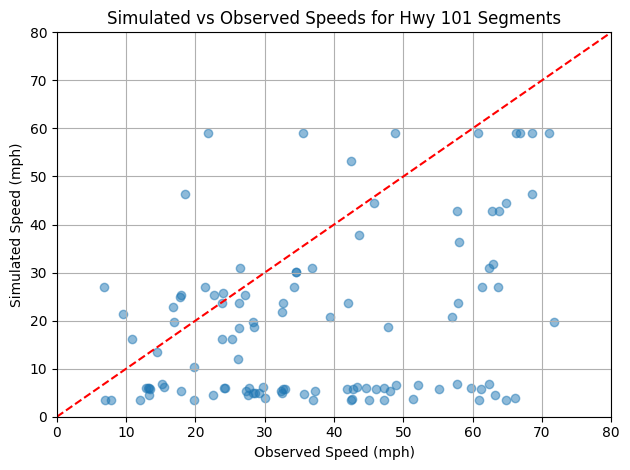

In [361]:
### visulaize the difference between simulated and observed speeds using a scatter plot
plt.scatter(observed_speeds, simulated_speeds, alpha=0.5)
plt.plot([0, 80], [0, 80], color='red', linestyle='--')  # 45-degree line
plt.title('Simulated vs Observed Speeds for Hwy 101 Segments')
plt.xlabel('Observed Speed (mph)')
plt.ylabel('Simulated Speed (mph)')
plt.xlim(0, 80)
plt.ylim(0, 80)
plt.grid()
plt.tight_layout()
plt.show()

In [285]:
worst_matching

[(413, 59.93791478389898),
 (526, 60.22338965470233),
 (133, 61.937709004857304),
 (458, 62.23684058437222),
 (345, 62.278220340681244),
 (196, 63.28313147115876),
 (537, 63.62524063396146),
 (680, 65.93334674691444),
 (475, 68.51039555390747),
 (450, 118.9598855174905)]

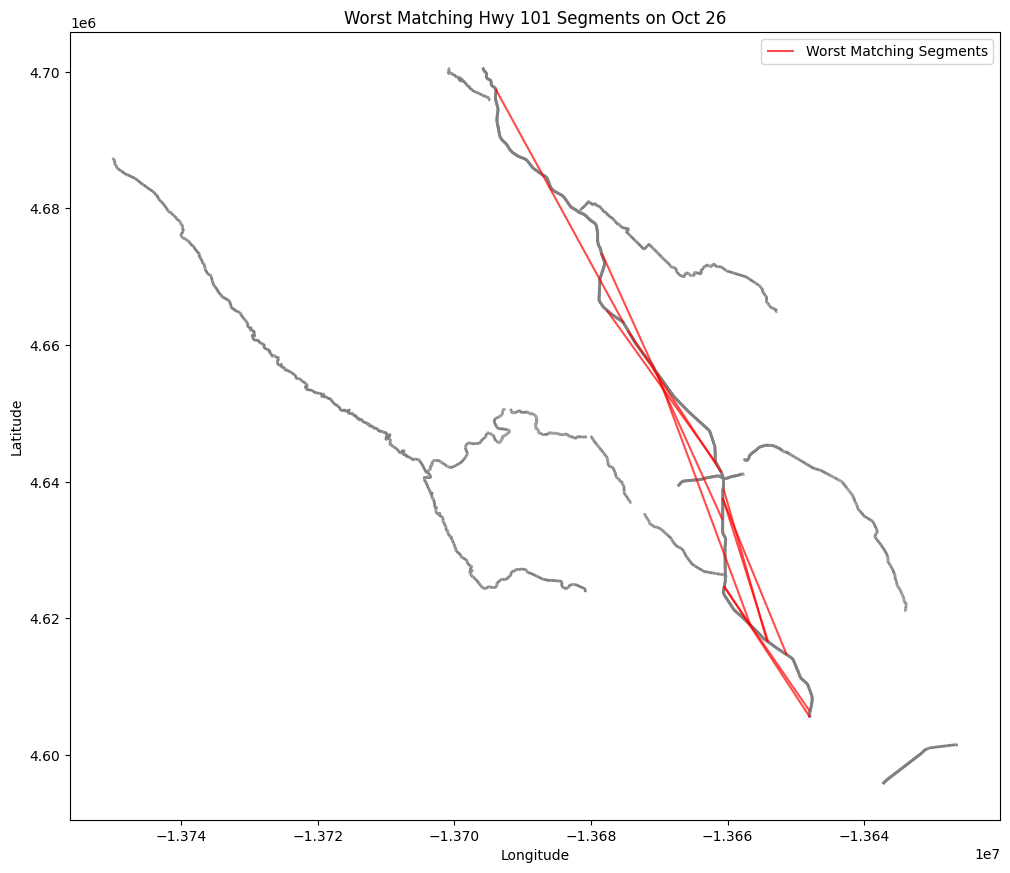

In [290]:
### Plot the locations of the worst matching segments on a map
import geopandas as gpd
from shapely.geometry import LineString
import contextily as ctx
import matplotlib.pyplot as plt

worst_segment_ids = [key for key, diff in worst_matching]
worst_segments_data = filtered_hw101_southbound.loc[worst_segment_ids]
gdf_worst_segments = gpd.GeoDataFrame(worst_segments_data, geometry=gpd.points_from_xy(worst_segments_data['Entrance_LON'], worst_segments_data['Entrance_LAT']))
gdf_worst_segments['Exit_Point'] = gpd.points_from_xy(worst_segments_data['Exit_LON'], worst_segments_data['Exit_LAT'])
gdf_worst_segments['geometry'] = gdf_worst_segments.apply(lambda row: LineString([row['geometry'], row['Exit_Point']]), axis=1)
gdf_worst_segments = gdf_worst_segments.drop(columns=['Exit_Point'])
gdf_worst_segments.set_crs(epsg=4326, inplace=True)
fig, ax = plt.subplots(figsize=(12, 12))
gdf_worst_segments.to_crs(epsg=3857).plot(ax=ax, color='red', alpha=0.7, label='Worst Matching Segments')
ax.legend()
### add highways background
highways = gpd.read_file('Highways.shp')
highways = highways.to_crs(epsg=3857)
highways.plot(ax=ax, color='gray', linewidth=2, zorder=1)

plt.title('Worst Matching Hwy 101 Segments on Oct 26')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


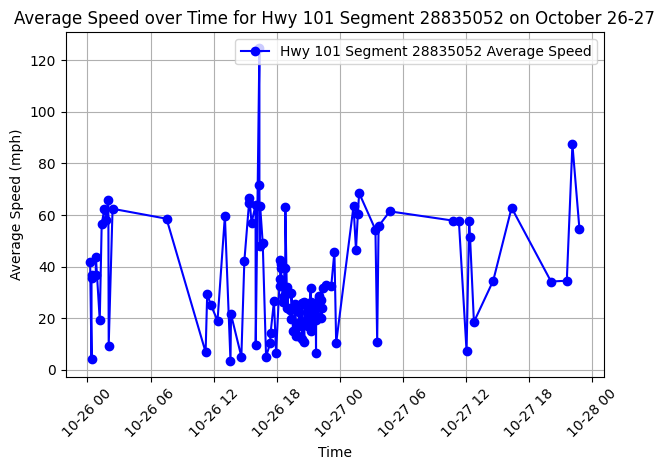

In [232]:
### for each ide in times_for_overlap, plot the average speed from filtered_hw101_southbound.loc[index]['Avg_Speed'] against the entry_time
entry_times = [time[1] for time in times_for_overlap]
avg_speeds = [filtered_hw101_southbound.loc[time[0]]['Avg_Speed'] for time in times_for_overlap]    
plt.plot(entry_times, avg_speeds, marker='o', label='Hwy 101 Segment 28835052 Average Speed', color='blue')
plt.title('Average Speed over Time for Hwy 101 Segment 28835052 on October 26-27')
plt.xlabel('Time')
plt.ylabel('Average Speed (mph)')
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

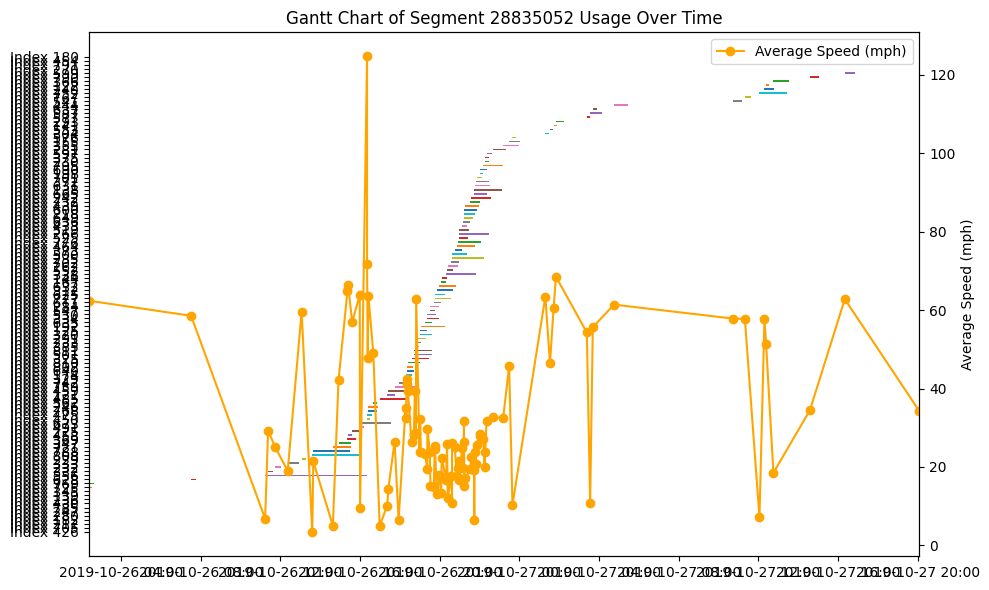

In [ ]:
### create a Gantt chart for the start and end times in times_for_overlap
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd 
fig, ax = plt.subplots(figsize=(10, 6))
for i, (index, start, end) in enumerate(times_for_overlap):
    ax.barh(i, end - start, left=start, height=0.4)

### plot a line with a second y axis that shows average speed for each index in times_for_overlap
ax2 = ax.twinx()
avg_speeds = [filtered_hw101_southbound.loc[index]['Avg_Speed'] for index, start, end in times_for_overlap]
ax2.plot([start for index, start, end in times_for_overlap], avg_speeds, color='orange', marker='o', label='Average Speed (mph)')

ax2.set_ylabel('Average Speed (mph)')
ax2.legend(loc='upper right')

ax.set_yticks(range(len(times_for_overlap)))
ax.set_yticklabels([f'Index {index}' for index, start, end in times_for_overlap])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))

plt.xlabel('Time')
plt.title('Gantt Chart of Segment 28835052 Usage Over Time')
### make the x labels diagonal
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()